# $(i, i+2)$ hopping interaction

We need to implement the next to nearest neighbours interaction for the hopping term.
Let us try three strategies:
1. do a simple $(i,i+1)$ interaction with the correct parameters and insert _a posteriori_ an identity MPO
2. make two sequential svds to obtain a three-site mpo (careful with the canonical form).
3. use the swap gate technique implemented by E. M. Stoudenmire and Steven R. White

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np

from ncon import ncon

from scipy.sparse import csc_array, kron
import scipy.sparse as sp
from scipy.linalg import svd

from qs_mps.utils import tensor_shapes, mpo_to_matrix, create_sequential_colors
from qs_mps.applications.tJ.ed_ham import *

import matplotlib.pyplot as plt

# default parameters of the plot layout
plt.rcParams["text.usetex"] = True  # use latex
plt.rcParams["font.size"] = 13
plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.constrained_layout.use"] = True

C:\Users\HP\Desktop\qs-mps\src\qs_mps\applications\tJ\ed_ham.py:15: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  Sz = (1/2) * sp.diags([1, 0, -1], 0, format="csr")


In [31]:
def swap_gate(d):
    W = np.zeros((d,d,d,d), dtype=int)
    for i in range(d):
        for j in range(d):
            W[j,i,i,j] = 1
    return W

swap_mpo = swap_gate(3)

In [2]:
def id_gate(d,chi):
    I = np.zeros((chi, chi, d, d))

    for a in range(chi):
        for s in range(d):
            I[a,a,s,s] = 1.0
    return I

I_mpo = id_gate(3,9)

In [33]:
I_mpo[7,7]

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [4]:
# Single-site identity
Id = sp.identity(3, format="csr").toarray()
O = csc_array((3, 3), dtype=complex).toarray()

# Spin operators
Sz = (1/2) * sp.diags([1, 0, -1], 0, format="csr")

S_plus  = sp.csr_matrix([[0, 0, 1],
                         [0, 0, 0],
                         [0, 0, 0]])

S_minus = sp.csr_matrix([[0, 0, 0],
                         [0, 0, 0],
                         [1, 0, 0]])

# Hole hopping operators

# hole goes into a spin up state
T_up_h   = sp.csr_matrix([[0, 1, 0],
                          [0, 0, 0],
                          [0, 0, 0]])

# hole goes into a spin down state
T_down_h = sp.csr_matrix([[0, 0, 0],
                          [0, 0, 0],
                          [0, 1, 0]])

# spin up goes into a hole state
T_h_up   = sp.csr_matrix([[0, 0, 0],
                          [1, 0, 0],
                          [0, 0, 0]])

# spin down goes into a hole state
T_h_down = sp.csr_matrix([[0, 0, 0],
                          [0, 0, 1],
                          [0, 0, 0]])

# Hole number operator
n_h = sp.csr_matrix([[0, 0, 0],
                     [0, 1, 0],
                     [0, 0, 0]])

C:\Users\HP\AppData\Local\Temp\ipykernel_39116\1154478551.py:6: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  Sz = (1/2) * sp.diags([1, 0, -1], 0, format="csr")


### $1 \quad (i,i+1)$ interaction plus _a posteriori_ identity mpo

We make the evolution following these steps:
1. (a) define parameters of the $(i,i+2)$ interaction
1. (b) exponentiate the hopping operators in the space of two sites using time step $\delta$ or $\delta /2$ for the 2nd order trotterization
1. (c) divide the left and right part of this two-site operator with svd
1. (d) separate the possible interactions in four families $(A,B,C,D)$. In which $(A,B)$ are even and do NOT commute within each other, and $(C,D)$ are odd and do not commute with each other. However, $[A,C]=[A,D]=0$. Thus, we can organize our trotter steps as $U(\delta / 2; A+C)  U(\delta; B+D) U (\delta / 2; A+C)$ with in total only three contractions needed with the mps.

To realize 1. (d), we need to contract the mpo of $A$ with the mpo of $C$, and the mpo of $B$ with the mpo of $D$, respectively. We do so by creating masks that tell us where are the operators that contract with each others, if any

### 1.(a)

In [57]:
# parameters for the (i,i+2) interaction
half_chain_length = 3
tp_up, tp_down = 16, 16
trotter_steps = 100
final_time = 2
delta = final_time/trotter_steps
n = 2*half_chain_length + 1

### 1.(b)

In [58]:
## helping functions
def U_i_ip2_tJ(tp_up, tp_down, delta):
    """
    U_i_ip2

    This function computes the exponential of the 2-site hamiltonian for the t-J model.
    It returns to versions: 
    1. one with a time step delta/2 to use at the initial and final step
    of the trotterization
    2. one with a time step delta to use in the bulk steps of the trotterization

    """

    # choose the hamiltonian parameters
    H_i_ip2 = (
    - (tp_up/8) * kron(T_up_h, T_h_up) 
    - (tp_up/8) * kron(T_h_up, T_up_h)
    - (tp_down/8) * kron(T_down_h, T_h_down) 
    - (tp_down/8) * kron(T_h_down, T_down_h)).toarray()

    # initial and final 2-site evolution operator
    op_ev_if = sp.linalg.expm(-1j * delta/2 * H_i_ip2)

    # bulk 2-site evolution operator
    op_ev_bulk = sp.linalg.expm(-1j * delta * H_i_ip2)
    
    return op_ev_if, op_ev_bulk

def evolution_mpo_svd_1_tJ(op_ev: np.ndarray, d: int=3, schmidt_tol: float=1e-15, trunc: bool=False):
    """
    evolution_mpo_svd

    This function takes the edges, and bulk 2-site evolution operators (of the t-J model) and performs an svd
    to separate the matrix into site i and site i+1. Reshaping the results of the svd
    we can obtain the mpo for those evolution operators (with bounded bond dimension D<=d^2)

    """
    op_ev = op_ev.reshape(d,d,d,d)
    op_ev = op_ev.transpose(0,2,1,3)
    op_ev = op_ev.reshape(d*d,d*d)

    u, s, v = svd(op_ev, full_matrices=False)

    if trunc:
        condition = s >= schmidt_tol
        s_trunc = np.extract(condition, s)
        s = s_trunc
        v = v[:len(s),:]

    site_i = u.reshape(d,d,u.shape[1])
    site_i = site_i[:, :, :len(s)]
    site_i = site_i.transpose(2,0,1)
    site_i = site_i.reshape(1,len(s),d,d)

    site_ip1 = ncon([np.diag(s), v],[[-1, 1],[1, -2]]).reshape(v.shape[0],d,d)
    site_ip1 = site_ip1.reshape(1,v.shape[0],d,d)
    site_ip1 = site_ip1.transpose(1,0,2,3)


    tol = 1e-15 * np.max(np.abs(site_i))
    site_i.real[np.abs(site_i.real) < tol] = 0
    site_i.imag[np.abs(site_i.imag) < tol] = 0
    
    tol = 1e-15 * np.max(np.abs(site_ip1))
    site_ip1.real[np.abs(site_ip1.real) < tol] = 0
    site_ip1.imag[np.abs(site_ip1.imag) < tol] = 0
    
    return site_i, site_ip1

In [59]:
# exponentials of a two-site matrix with delta of delta/2
op_ev_half, op_ev_delta = U_i_ip2_tJ(tp_up, tp_down, delta)

### 1.(c)

In [60]:
# with SVD get the left and right part for A,B,C,D with the enlarged identity
site_i_delta_half, site_ip2_delta_half = evolution_mpo_svd_1_tJ(op_ev_half, trunc=True)
site_i_delta, site_ip2_delta = evolution_mpo_svd_1_tJ(op_ev_delta, trunc=True)
tensor_shapes([site_i_delta_half, site_ip2_delta_half])
id_enlarged_mpo = id_gate(3,site_i_delta_half.shape[1])

(1, 6, 3, 3)
(6, 1, 3, 3)


### 1.(d)

In [61]:
## helping functions
def make_mask_even(n):
    mask_id_A = [(i%4 == 1) if (i+1)<n else False for i in range(n)]
    mask_C_l = [(i%4 == 1) if (i+2)<n else False for i in range(n)]
    return mask_id_A, mask_C_l

def make_mask_odd(n):
    mask_id_B = [(i%4 == 3) if (i+1)<n else False for i in range(n)]
    mask_D_l = [(i%4 == 3) if (i+2)<n else False for i in range(n)]
    return mask_id_B, mask_D_l

def make_trott_mpo(n, op_l, i_en, op_r, id, parity: str="even", d: int=3):
    if parity == "even":
        mask_1, mask_2 = make_mask_even(n)
    elif parity == "odd":
        mask_1, mask_2 = make_mask_odd(n)

    mpo_trott = [id] * n

    idx = 0
    for mask_step_1, mask_step_2 in zip(mask_1, mask_2):
        if mask_step_1:
            mpo_trott[idx] = i_en.copy()
            mpo_trott[idx-1] = op_l.copy()
            mpo_trott[idx+1] = op_r.copy()
        if mask_step_2:
            mpo_trott[idx] = ncon([mpo_trott[idx],op_l],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((mpo_trott[idx].shape[0],mpo_trott[idx].shape[1]*op_l.shape[1],d,d))
            mpo_trott[idx+1] = ncon([mpo_trott[idx+1],i_en],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((mpo_trott[idx+1].shape[0]*i_en.shape[0],i_en.shape[1],d,d))
            mpo_trott[idx+2] = op_r.copy()
        idx += 1
    return mpo_trott

In [62]:
## helping functions
def make_trott_mpo_eo_oe(n, op_l, op_r, parity: str="eo", d: int=3):
    if parity == "eo":
        mpo_even = ncon([op_l,op_r],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((op_l.shape[0]*op_r.shape[0],op_l.shape[1]*op_r.shape[1],d,d))
        mpo_odd = ncon([op_r,op_l],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((op_l.shape[0]*op_r.shape[0],op_l.shape[1]*op_r.shape[1],d,d))
    elif parity == "oe":
        mpo_even = ncon([op_r,op_l],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((op_l.shape[0]*op_r.shape[0],op_l.shape[1]*op_r.shape[1],d,d))
        mpo_odd = ncon([op_l,op_r],[[-1,-3,-5,1],[-2,-4,1,-6]]).reshape((op_l.shape[0]*op_r.shape[0],op_l.shape[1]*op_r.shape[1],d,d))

    mpo_trott = []

    mpo_trott.append(op_l)
    for i in range(1,n-1):
        if (i%2) == 0:
            mpo_trott.append(mpo_even)
        elif (i%2) == 1:
            mpo_trott.append(mpo_odd)
    
    mpo_trott.append(op_r)
    return mpo_trott

In [63]:
make_trott_mpo_eo_oe(n=5, op_l=site_i_delta_half, )

TypeError: make_trott_mpo_eo_oe() missing 1 required positional argument: 'op_r'

In [ ]:
id_mpo = sp.identity(n=3).toarray().reshape((1,1,3,3))
print(id_mpo.shape)
trotter_step_delta_half = make_trott_mpo(n, site_i_delta_half, id_enlarged_mpo, site_ip2_delta_half, id_mpo, parity="even")
trotter_step_delta = make_trott_mpo(n, site_i_delta, id_enlarged_mpo, site_ip2_delta, id_mpo, parity="odd")
tensor_shapes(trotter_step_delta_half, prnt=False), tensor_shapes(trotter_step_delta,prnt=False)

(1, 1, 3, 3)


([(1, 6, 3, 3),
  (6, 36, 3, 3),
  (36, 6, 3, 3),
  (6, 1, 3, 3),
  (1, 6, 3, 3),
  (6, 6, 3, 3),
  (6, 1, 3, 3)],
 [(1, 1, 3, 3),
  (1, 1, 3, 3),
  (1, 6, 3, 3),
  (6, 36, 3, 3),
  (36, 6, 3, 3),
  (6, 1, 3, 3),
  (1, 1, 3, 3)])

In [64]:
def mpo_ev_trotter_i_ip2_pipeline(n, tp_up, tp_down, delta, trunc=False):
    op_ev_half, op_ev_delta = U_i_ip2_tJ(tp_up, tp_down, delta)
    site_i_delta_half, site_ip2_delta_half = evolution_mpo_svd_1_tJ(op_ev_half,trunc=trunc)
    site_i_delta, site_ip2_delta = evolution_mpo_svd_1_tJ(op_ev_delta,trunc=trunc)
    id_enlarged_mpo = id_gate(3,site_i_delta_half.shape[1])
    id_mpo = sp.identity(n=3).toarray().reshape((1,1,3,3))
    trotter_step_delta_half = make_trott_mpo(n, site_i_delta_half, id_enlarged_mpo, site_ip2_delta_half, id_mpo, parity="even")
    trotter_step_delta = make_trott_mpo(n, site_i_delta, id_enlarged_mpo, site_ip2_delta, id_mpo, parity="odd")
    return trotter_step_delta_half, trotter_step_delta

## Convert to matrix to make a quick test

In [65]:
half_chain_length = 3
tp_up, tp_down = 16, 16
trotter_steps = 100
final_time = 2
delta = final_time/trotter_steps
n = 2*half_chain_length + 1

In [66]:
U_half = mpo_to_matrix(trotter_step_delta_half)
U_delta = mpo_to_matrix(trotter_step_delta)

U_step_nnn = U_half @ U_delta @ U_half

In [67]:
half_chain_length = 3
t_up = 1
t_down = 1
Jz = 10
J_perp = 1
eps = 0
V = 0
trotter_steps = 200
final_time = 5
delta = final_time / trotter_steps

In [68]:
# mpo_ev_i_ip1_eo, mpo_ev_i_ip1_oe = mpo_ev_trotter_i_ip1_pipeline(n, Jz, J_perp, t_up, t_down, V, delta)
mpo_ev_i_ip1 = mpo_ev_trotter_i_ip1_pipeline_alone(n, Jz, J_perp, t_up, t_down, V, delta)
# tensor_shapes(mpo_ev_i_ip1_oe)
tensor_shapes(mpo_ev_i_ip1)

(1, 81, 3, 3)
(81, 9, 3, 3)
(9, 81, 3, 3)
(81, 9, 3, 3)
(9, 81, 3, 3)
(81, 9, 3, 3)
(9, 1, 3, 3)


[(1, 81, 3, 3),
 (81, 9, 3, 3),
 (9, 81, 3, 3),
 (81, 9, 3, 3),
 (9, 81, 3, 3),
 (81, 9, 3, 3),
 (9, 1, 3, 3)]

In [69]:
# U_eo = mpo_to_matrix(mpo_ev_i_ip1_eo)
# U_oe = mpo_to_matrix(mpo_ev_i_ip1_oe)
U_eo = mpo_to_matrix(mpo_ev_i_ip1)

In [70]:
occup_tot_nnn = []
for tp_up in [0,1,4,8,16]:
    tp_down = tp_up
    H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, tp_up=tp_up, tp_down=tp_down, n_holes=1)
    trotter_step_delta_half, trotter_step_delta = mpo_ev_trotter_i_ip2_pipeline(n, tp_up, tp_down, delta)
    U_half = mpo_to_matrix(trotter_step_delta_half)
    U_delta = mpo_to_matrix(trotter_step_delta)
    
    U_step_nnn = U_half @ U_delta @ U_half
    # U_step = U_eo @ U_step_nnn @ U_oe
    U_step = U_eo @ U_step_nnn

    psi_ev = psi_init.copy()

    obs = ['h_loc', 'm_loc']
    ops_h = local_hole_occupation(n)
    ops_m = local_mag_occupation(n)

    occup_tot_h = []
    occup_tot_m = []

    for t in range(trotter_steps):
        print(f"trotter step: {t}")
        
        psi_ev = U_step @ psi_ev

        if 'h_loc' in obs:
            occup = []
            for op in ops_h:
                occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
                # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
            occup_tot_h.append(occup)

        if 'm_loc' in obs:
            occup = []
            for op in ops_m:
                occup.append((psi_ev.conjugate().T @ op @ psi_ev).real)
                # occup.append(((psi_ev.conjugate().T @ op @ psi_ev).real).toarray())
            occup_tot_m.append(occup)
    occup_tot_nnn.append(occup_tot_h)

trotter step: 0
trotter step: 1
trotter step: 2
trotter step: 3
trotter step: 4
trotter step: 5
trotter step: 6
trotter step: 7
trotter step: 8
trotter step: 9
trotter step: 10
trotter step: 11
trotter step: 12
trotter step: 13
trotter step: 14
trotter step: 15
trotter step: 16
trotter step: 17
trotter step: 18
trotter step: 19
trotter step: 20
trotter step: 21
trotter step: 22
trotter step: 23
trotter step: 24
trotter step: 25
trotter step: 26
trotter step: 27
trotter step: 28
trotter step: 29
trotter step: 30
trotter step: 31
trotter step: 32
trotter step: 33
trotter step: 34
trotter step: 35
trotter step: 36
trotter step: 37
trotter step: 38
trotter step: 39
trotter step: 40
trotter step: 41
trotter step: 42
trotter step: 43
trotter step: 44
trotter step: 45
trotter step: 46
trotter step: 47
trotter step: 48
trotter step: 49
trotter step: 50
trotter step: 51
trotter step: 52
trotter step: 53
trotter step: 54
trotter step: 55
trotter step: 56
trotter step: 57
trotter step: 58
trotter

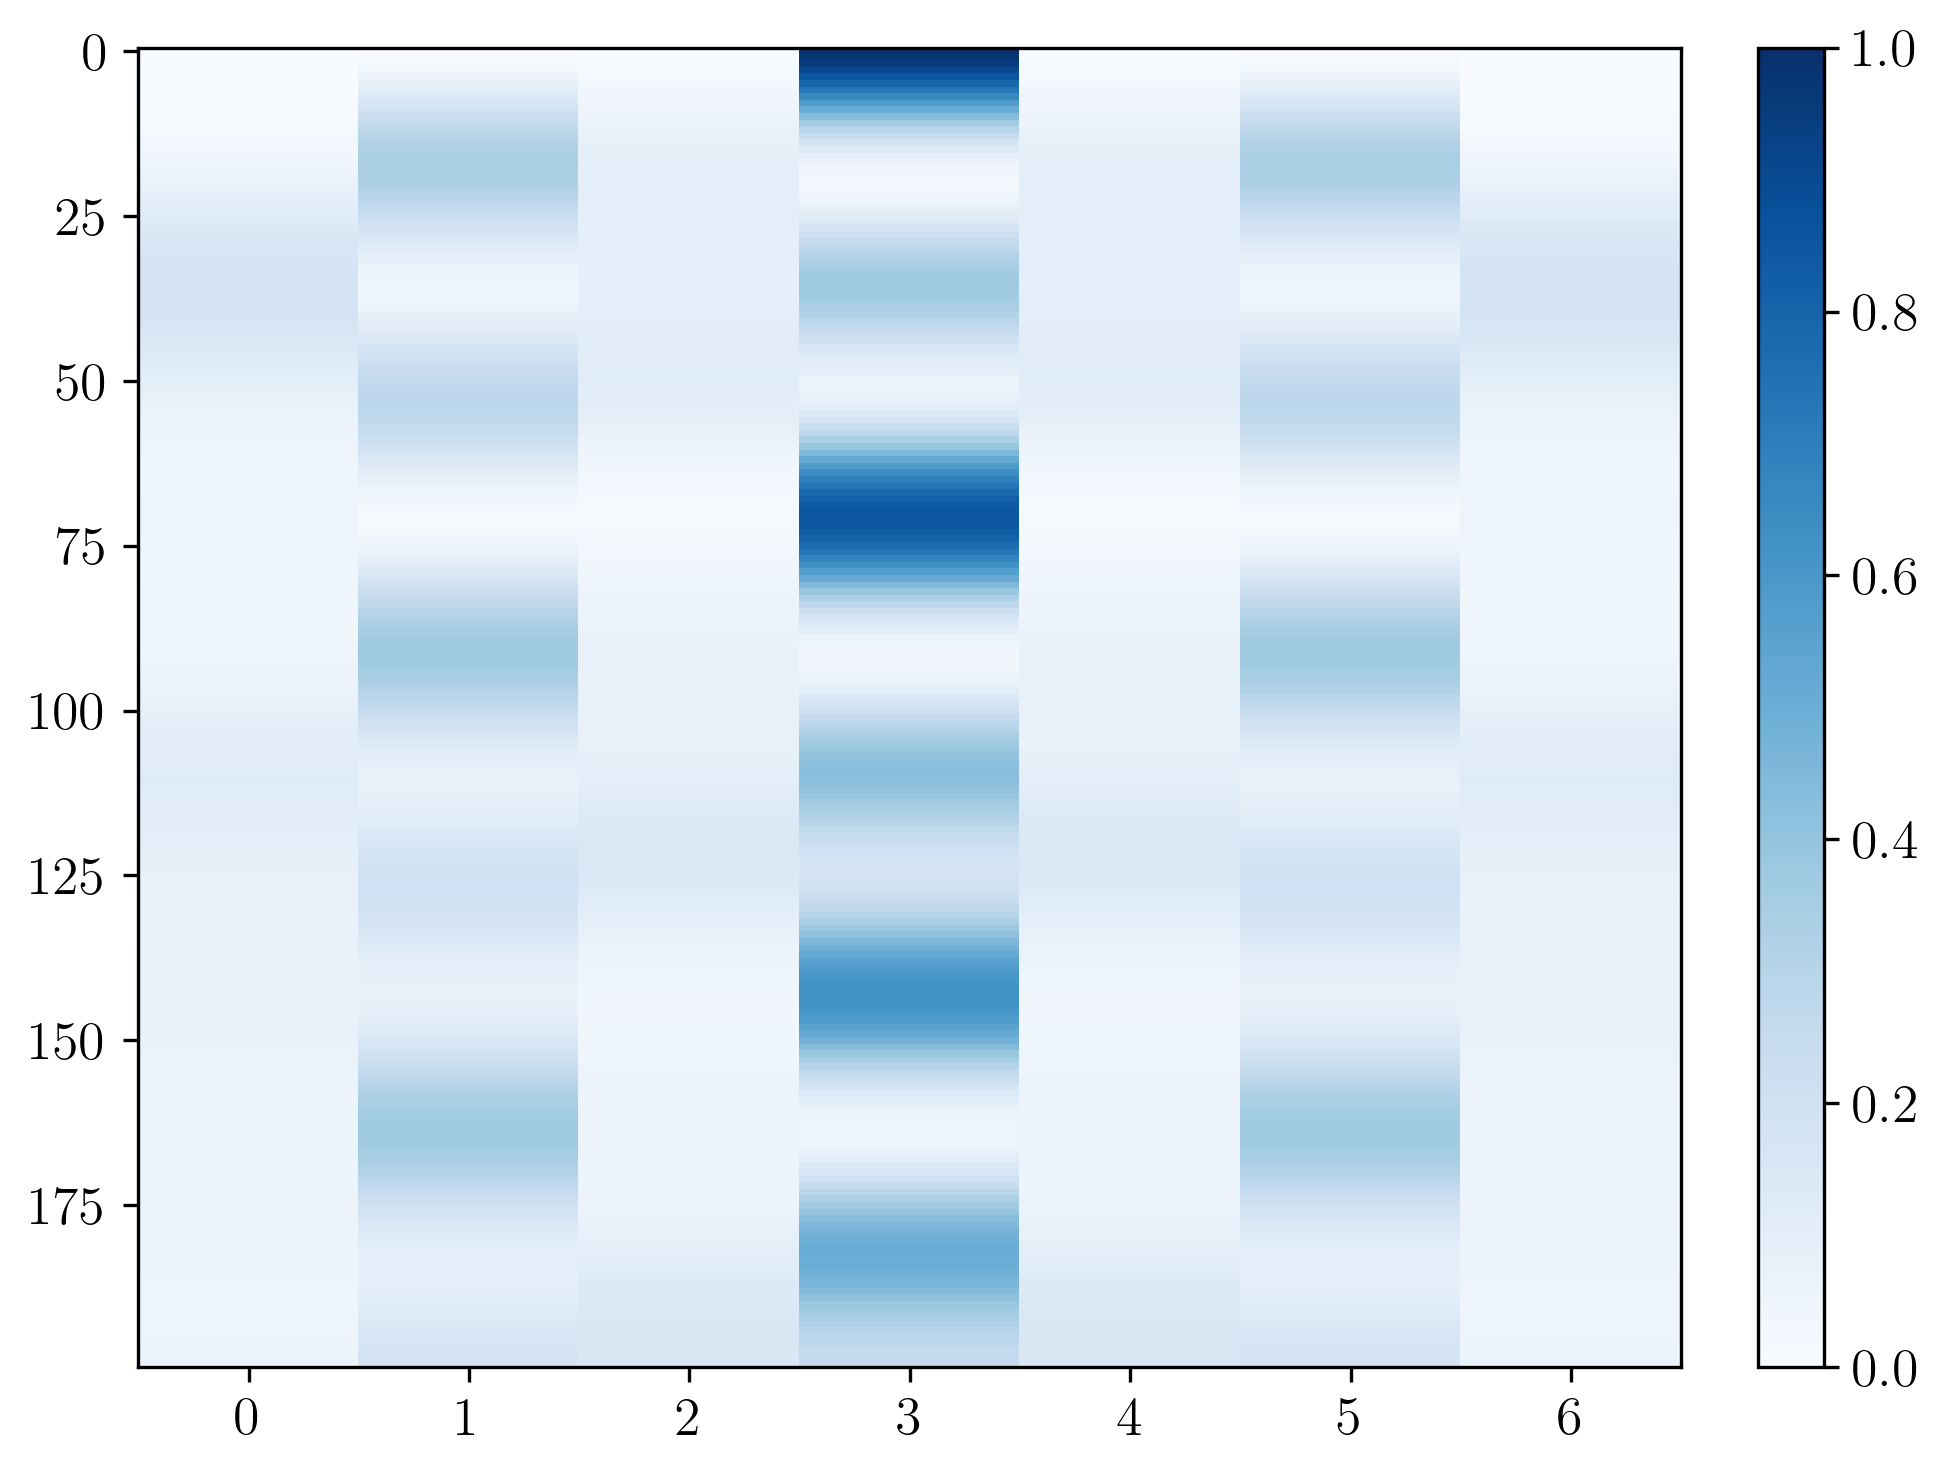

In [71]:
plt.imshow(np.asarray(occup_tot_h), vmin=0, vmax=1, aspect='auto', cmap="Blues")
plt.colorbar()

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

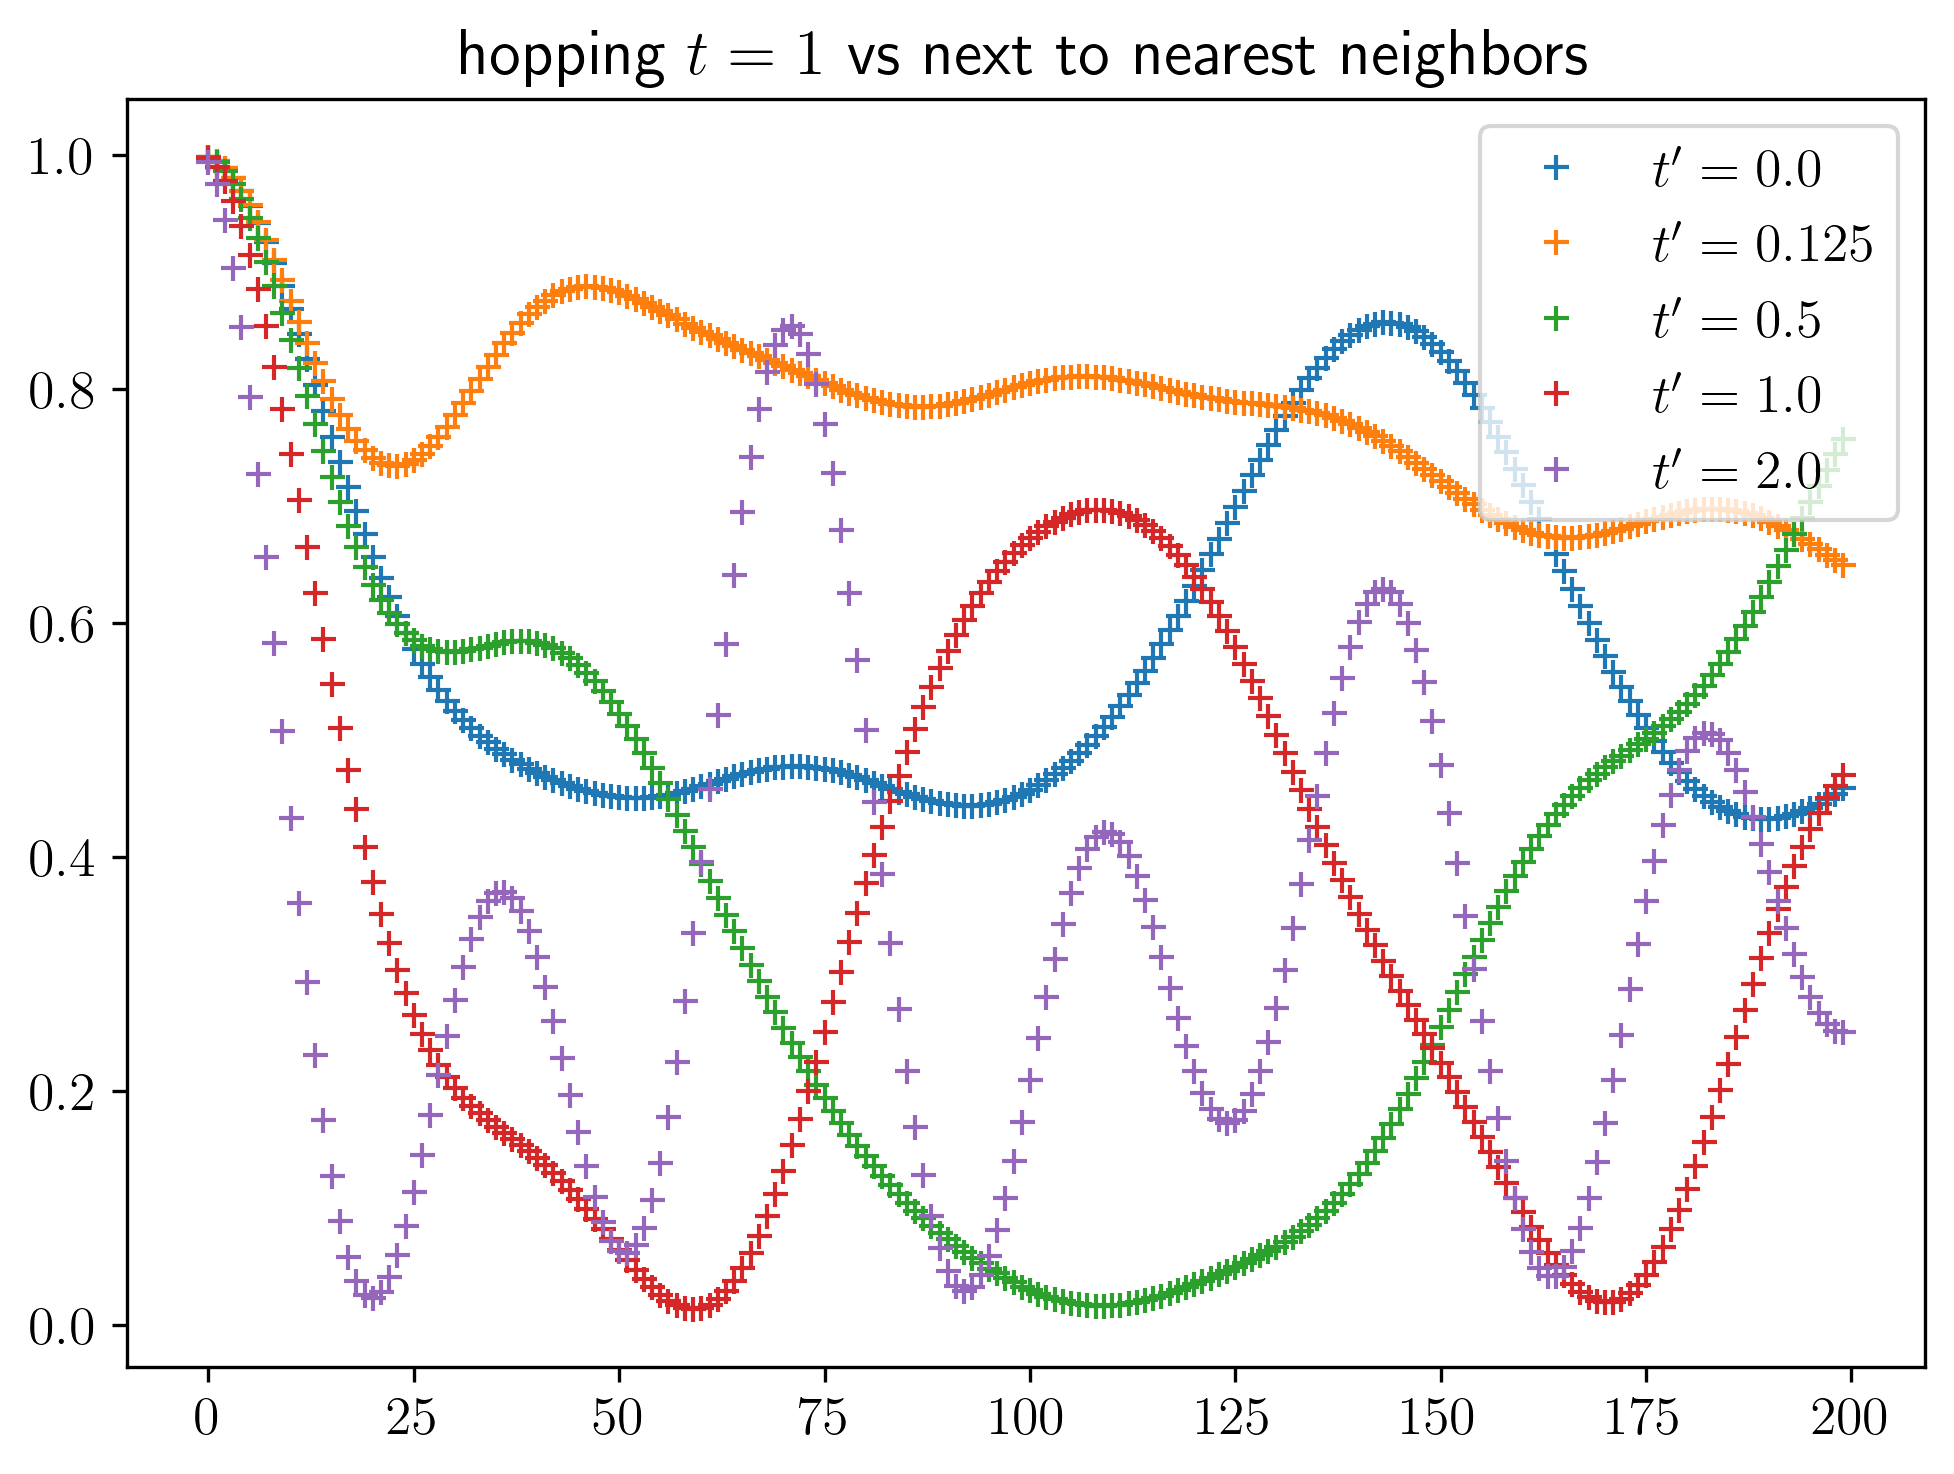

In [72]:
tp_ups = [0,1,4,8,16]
tp_downs = [0,1,4,8,16]
for tp_up, tp_down in zip(tp_ups, tp_downs):
    H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, tp_up=tp_up, tp_down=tp_down)
    occup_tot, _ = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time)
    plt.plot(np.asarray(occup_tot[0])[:,3],'+', label=f'$t\' ={tp_up/8}$')

plt.title(f"hopping $t={1}$ vs next to nearest neighbors")
plt.legend()

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

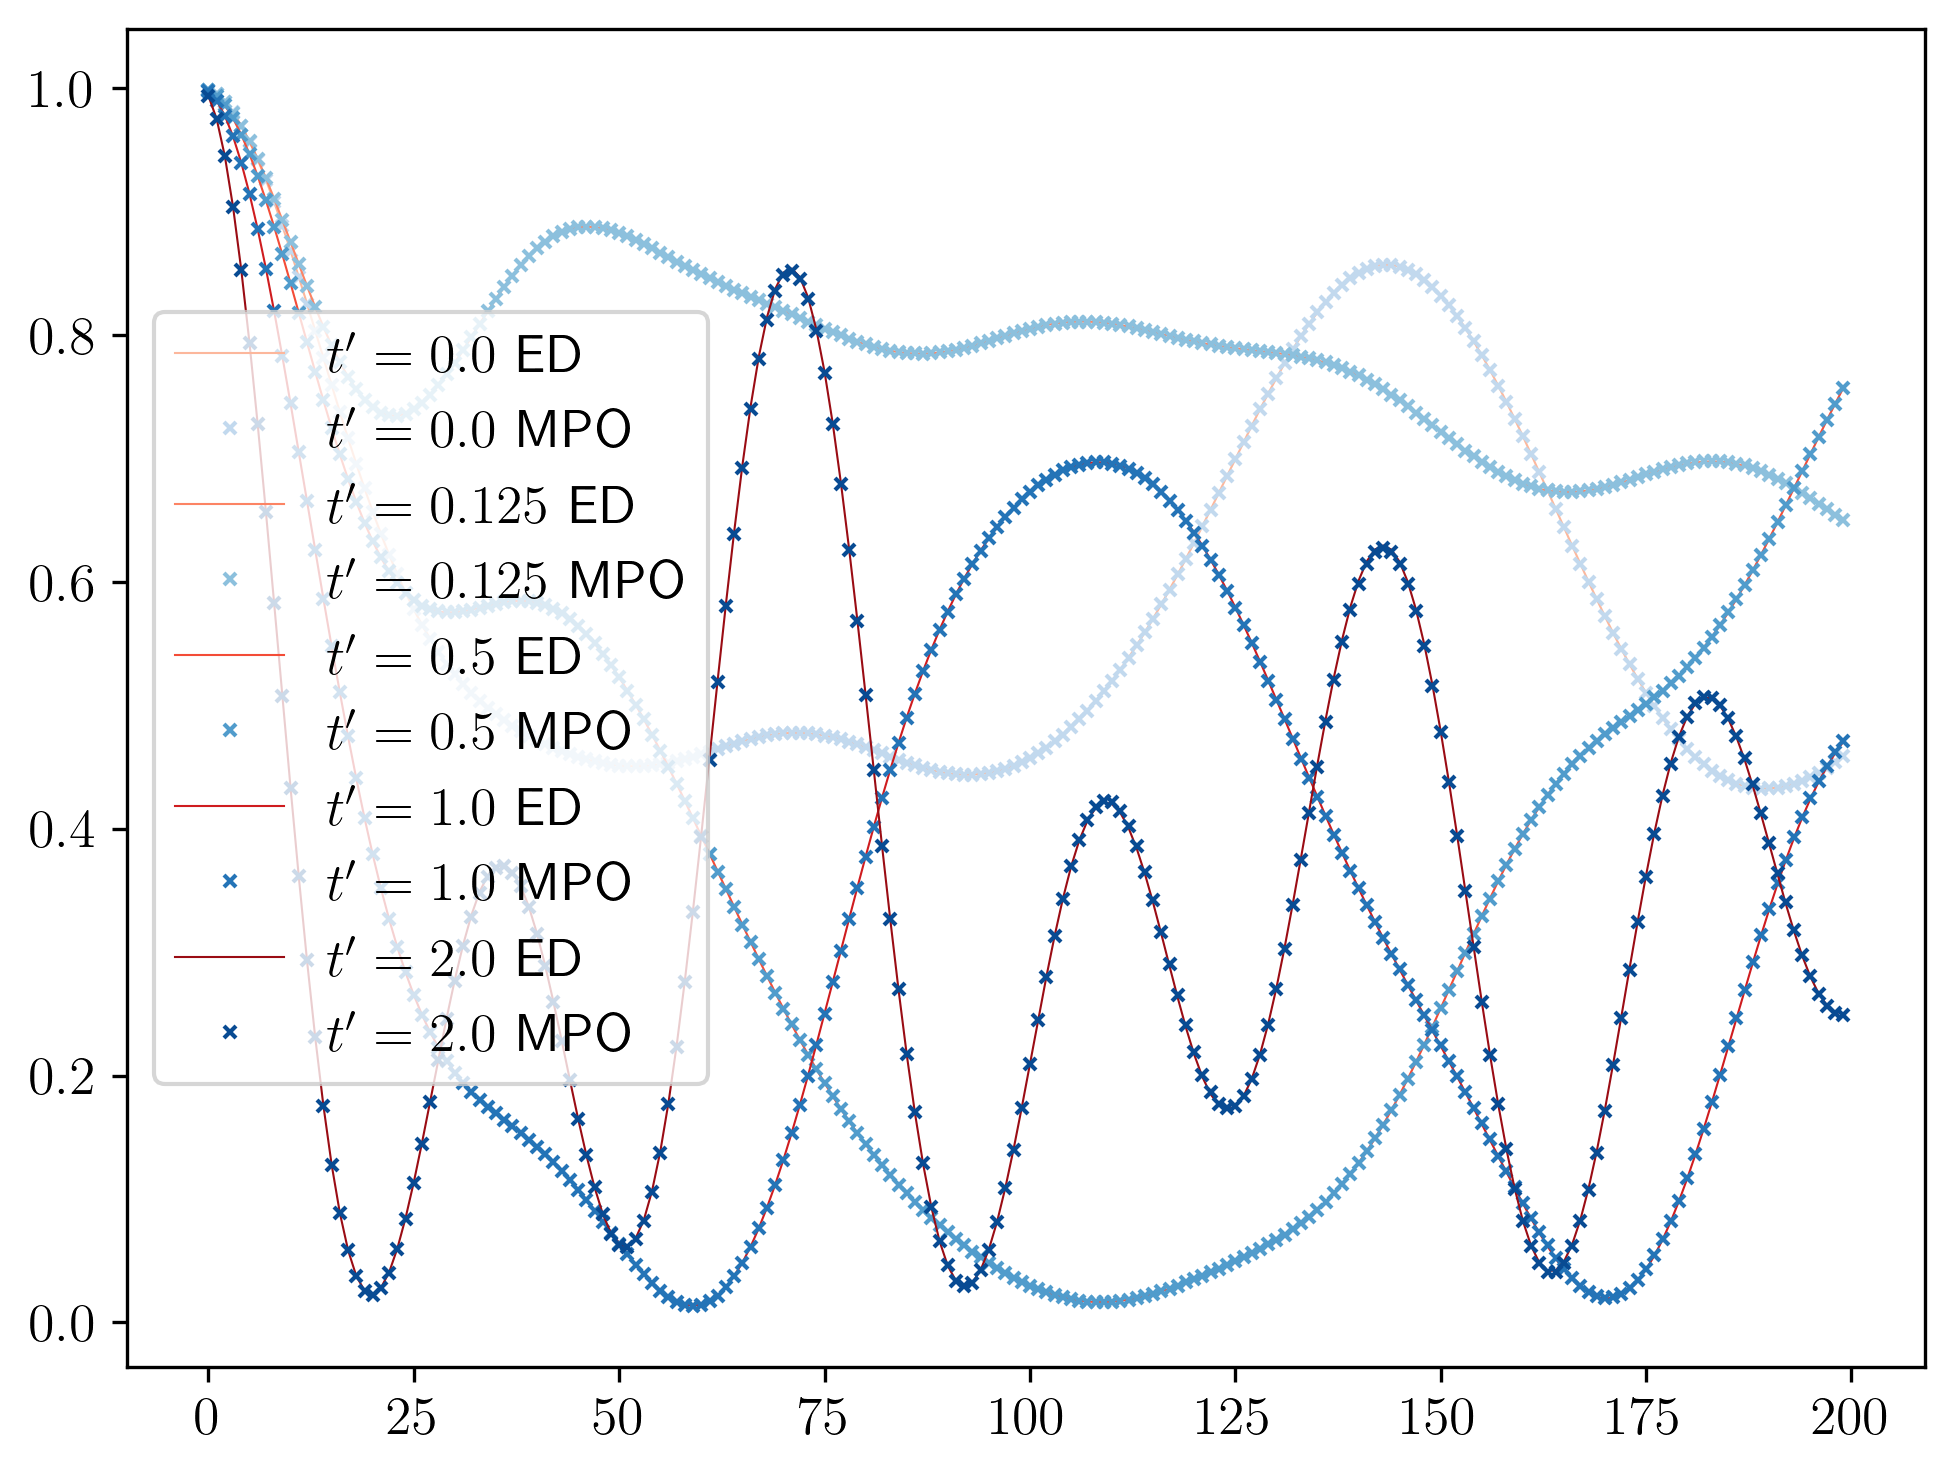

In [73]:
i = 0
colors_mpo = create_sequential_colors(len(tp_ups)*4, colormap_name='Blues')
colors_ed = create_sequential_colors(len(tp_ups)*4, colormap_name='Reds')
for tp_up, tp_down in zip(tp_ups, tp_downs):
    H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, tp_up=tp_up, tp_down=tp_down)
    occup_tot, _ = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time)
    plt.plot(np.asarray(occup_tot[0])[:,3], '-', color=colors_ed[2*i+5+i], linewidth=0.5, label=f'$t\' ={tp_up/8}$ ED')
    plt.plot(np.asarray(occup_tot_nnn[i])[:,3], 'x', markersize=3, color=colors_mpo[2*i+5+i], label=f'$t\' ={tp_up/8}$ MPO')
    i += 1
plt.legend()

<>:49: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:49: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_36160\2261495015.py:49: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  mlines.Line2D([], [], color='red', linestyle='-', linewidth=1.5, label='$\delta^2$')


Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

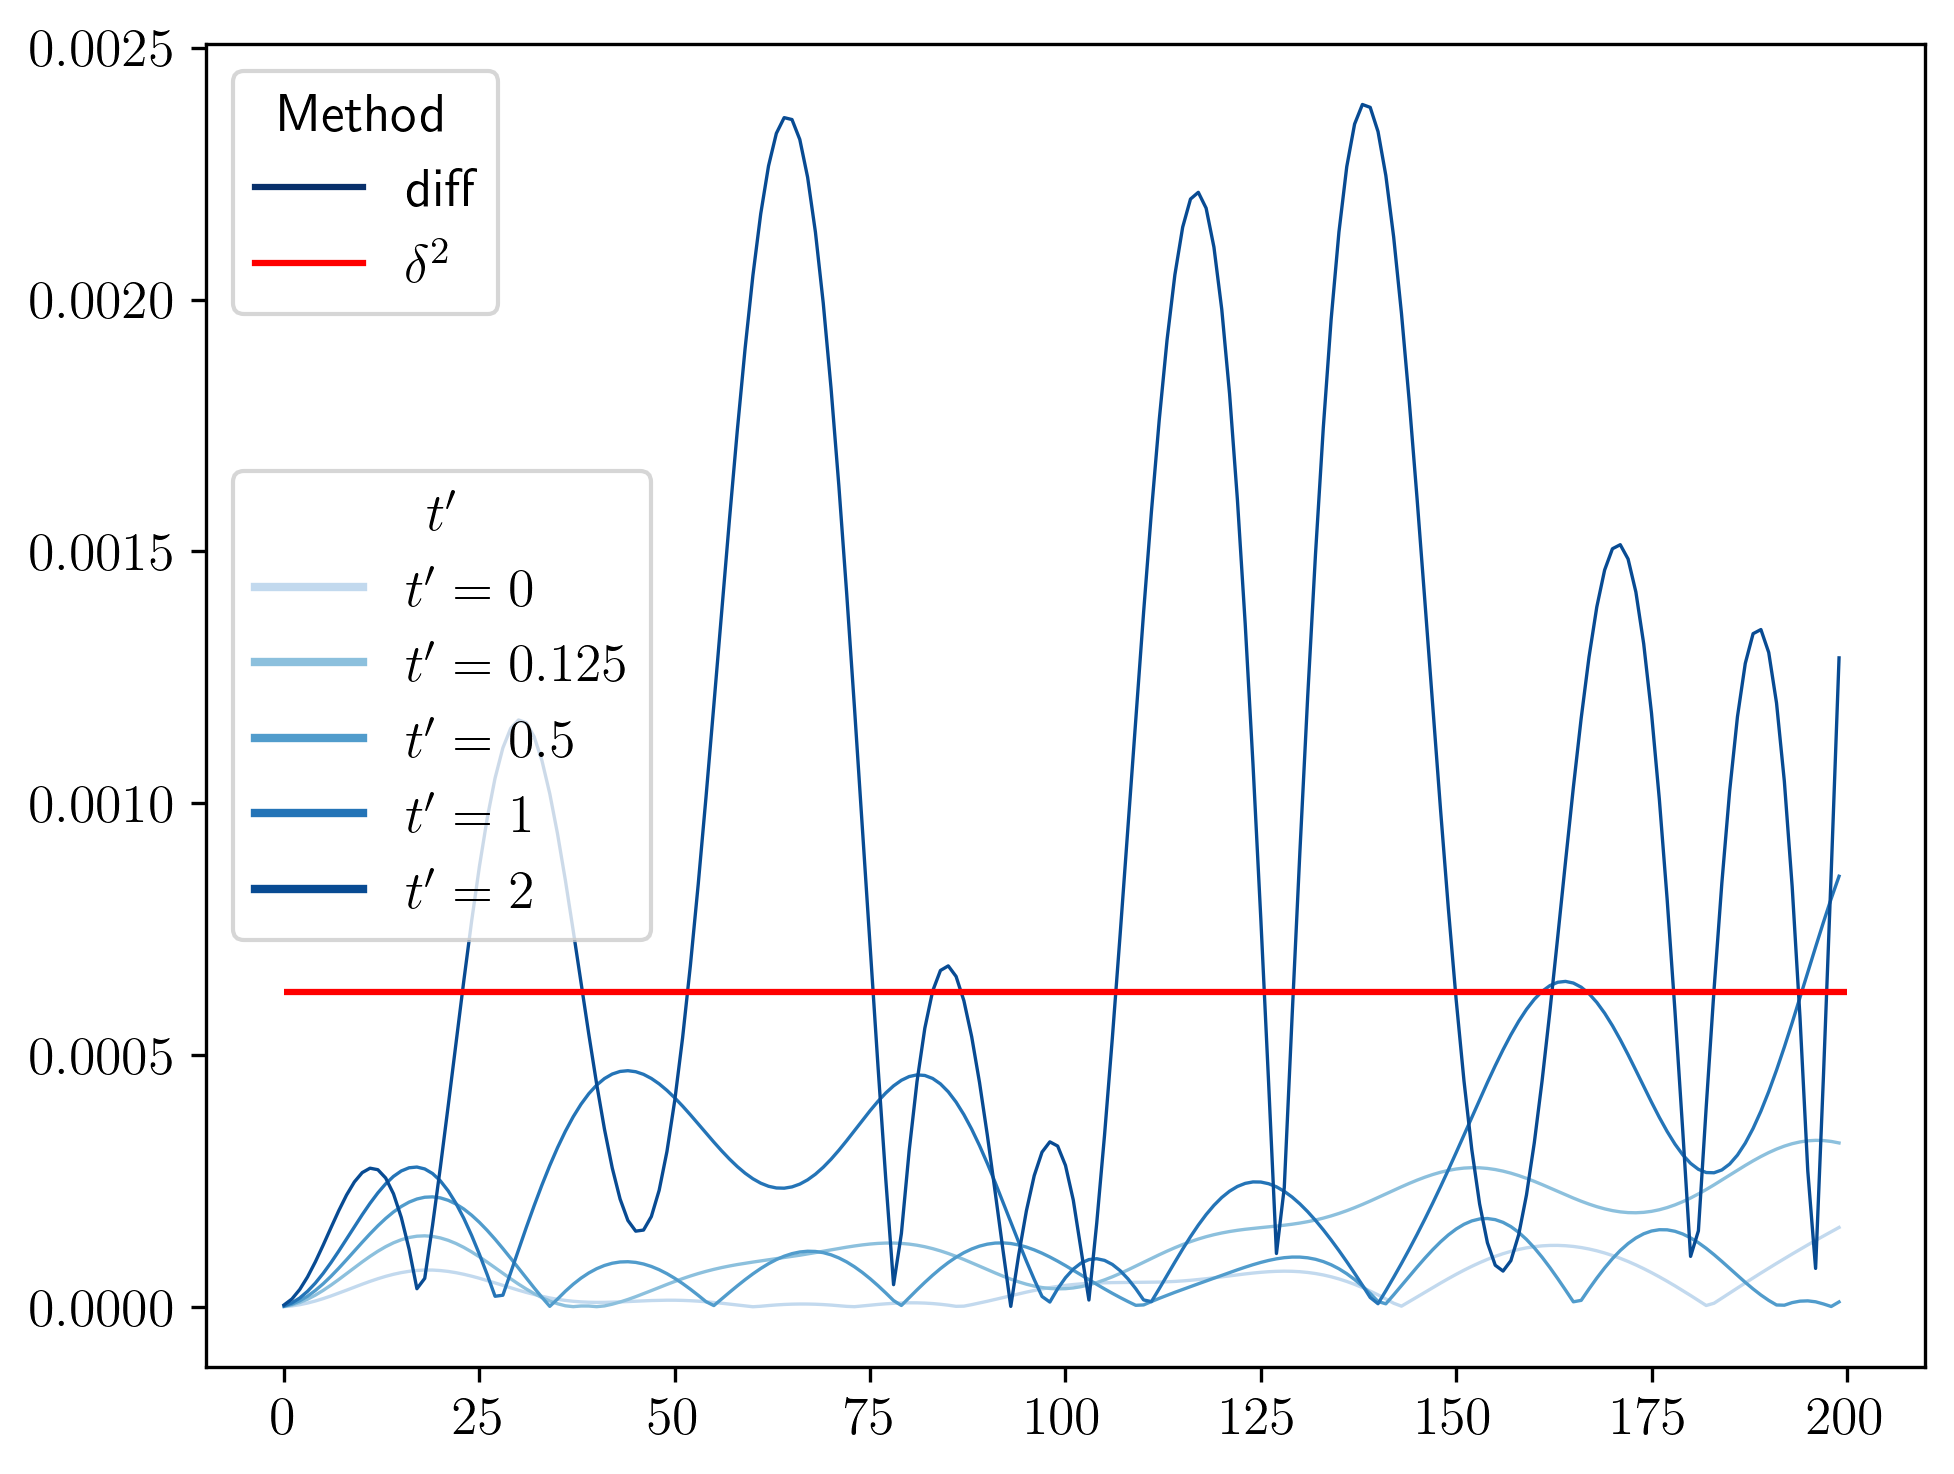

In [74]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

fig, ax = plt.subplots()

# colormap for the parameter sweep
tp_vals = np.array(tp_ups) / 8
colors = create_sequential_colors(len(tp_vals)*4, colormap_name='Blues')

# --- Plot data ---
for i, (tp_up, tp_down) in enumerate(zip(tp_ups, tp_downs)):
    H_ev, psi_init = half_hole_quench_init(
        half_chain_length, t_up, t_down, Jz, J_perp, eps, V,
        tp_up=tp_up, tp_down=tp_down
    )

    occup_tot, _ = half_hole_quench_evolution(
        half_chain_length, H_ev, psi_init, trotter_steps, final_time
    )

    c = colors[i+5+2*i]

    # # ED = line
    # ax.plot(
    #     np.asarray(occup_tot[0])[:, 3],
    #     '-',
    #     color=c,
    #     linewidth=0.8
    # )

    # MPO = marker
    ax.plot(
        abs(np.asarray(occup_tot[0])[:, 3] - np.asarray(occup_tot_nnn[i])[:, 3]),
        '-',
        color=c,
        linewidth=0.8
    )

ax.hlines(y=delta**2, xmin=0, xmax=trotter_steps, colors='r')

# ---------------------------------------------------
# Legend 1: meaning of style (ED vs MPO)
# use dark color for visibility
dark = colors[-1]

style_handles = [
    mlines.Line2D([], [], color=dark, linestyle='-', linewidth=1.5, label='diff'),
    mlines.Line2D([], [], color='red', linestyle='-', linewidth=1.5, label='$\delta^2$')
]

leg1 = ax.legend(handles=style_handles, loc='upper left', title='Method')
ax.add_artist(leg1)

# ---------------------------------------------------
# Legend 2: parameter values t'
param_handles = [
    mlines.Line2D([], [], color=colors[i+5+2*i], linewidth=2,
                  label=fr"$t'={tp_vals[i]:.3g}$")
    for i in range(len(tp_vals))
]

ax.legend(handles=param_handles, loc='center left', title=r"$t'$")

plt.show()


## Full TEBD

In [52]:
def neel_prod_state(n):
    spin_up_tn = np.array([1,0,0]).reshape((1,3,1))
    hole_tn = np.array([0,1,0]).reshape((1,3,1))
    spin_down_tn = np.array([0,0,1]).reshape((1,3,1))
    tn_list = [spin_up_tn if (i%2) == 0 else spin_down_tn for i in range(n)]
    return tn_list

In [41]:
half_chain_length = 3
L = 2*half_chain_length + 1
t_up = 1
t_down = 1
Jz = 10
J_perp = 1
eps = 0
V = 0
trotter_steps = 100
final_time = 2
delta = final_time / trotter_steps

In [42]:
from qs_mps.mps_class import MPS

spin_up_tn = np.array([1,0,0]).reshape((1,3,1))
hole_tn = np.array([0,1,0]).reshape((1,3,1))
spin_down_tn = np.array([0,0,1]).reshape((1,3,1))
L = 2*half_chain_length + 1

mps_chain = MPS(L=L, d=3, model='tj', chi=1)
# init_state = [hole_tn]*(L//2 - 1) + [spin_up_tn]*2 + [hole_tn]*(L//2 - 1)
neel_state = neel_prod_state(half_chain_length)
init_state = neel_state + [hole_tn] + neel_state
mps_chain.sites = init_state.copy()

loc_mag = []
for i in range(1,mps_chain.L+1):
    mps_chain.local_param(site=i, op="Z")
    loc_mag.append(mps_chain.mpo_first_moment().real)

loc_mag

C:\Users\HP\Desktop\qs-mps\src\qs_mps\mps_class.py:1822: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  operator = diags([1, 0, -1], 0, format="csr").toarray()


[array(1.), array(-1.), array(1.), array(0.), array(1.), array(-1.), array(1.)]

In [43]:
# mpo_i_ip1 = mpo_ev_trotter_i_ip1_pipeline(L, Jz, J_perp, t_up, t_down, V, delta)
mpo_i_ip1_eo, mpo_i_ip1_oe = mpo_ev_trotter_i_ip1_pipeline(L, Jz, J_perp, t_up, t_down, V, delta)
mpo_i_ip2_delta_half, mpo_i_ip2_delta = mpo_ev_trotter_i_ip2_pipeline(L, tp_up, tp_down, delta)
# mps_chain.w_dag = [mpo_i_ip1.copy(), mpo_i_ip2_delta_half.copy(), mpo_i_ip2_delta.copy(), mpo_i_ip2_delta_half.copy()]
mps_chain.w_dag = [mpo_i_ip1_eo.copy(), mpo_i_ip2_delta_half.copy(), mpo_i_ip2_delta.copy(), mpo_i_ip2_delta_half.copy(),mpo_i_ip1_oe.copy()]
# mps_chain.w_dag = [mpo_i_ip1.copy()]

In [44]:
(
errs,
entrs,
svs,
local_magnetization,
ovlps,
chi_sat,
) = mps_chain.TEBD_variational_tJ(trotter_steps=trotter_steps, where=mps_chain.L//2, chi_max=20, obs=['lh'])

C:\Users\HP\Desktop\qs-mps\src\qs_mps\mps_class.py:1824: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  operator = diags([0, 1, 0], 0, format="csr").toarray()


trotter_step: 0


i,i+2 interaction delta/2: 100%|██████████| 5/5 [00:00<00:00,  9.87it/s]


trotter_step: 1


i,i+2 interaction delta/2: 100%|██████████| 5/5 [00:00<00:00, 12.83it/s]


...

i,i+2 interaction delta/2: 100%|██████████| 5/5 [00:00<00:00, 10.96it/s]


trotter_step: 98


i,i+2 interaction delta/2: 100%|██████████| 5/5 [00:00<00:00,  6.63it/s]


trotter_step: 99


i,i+2 interaction delta/2: 100%|██████████| 5/5 [00:00<00:00,  7.19it/s]


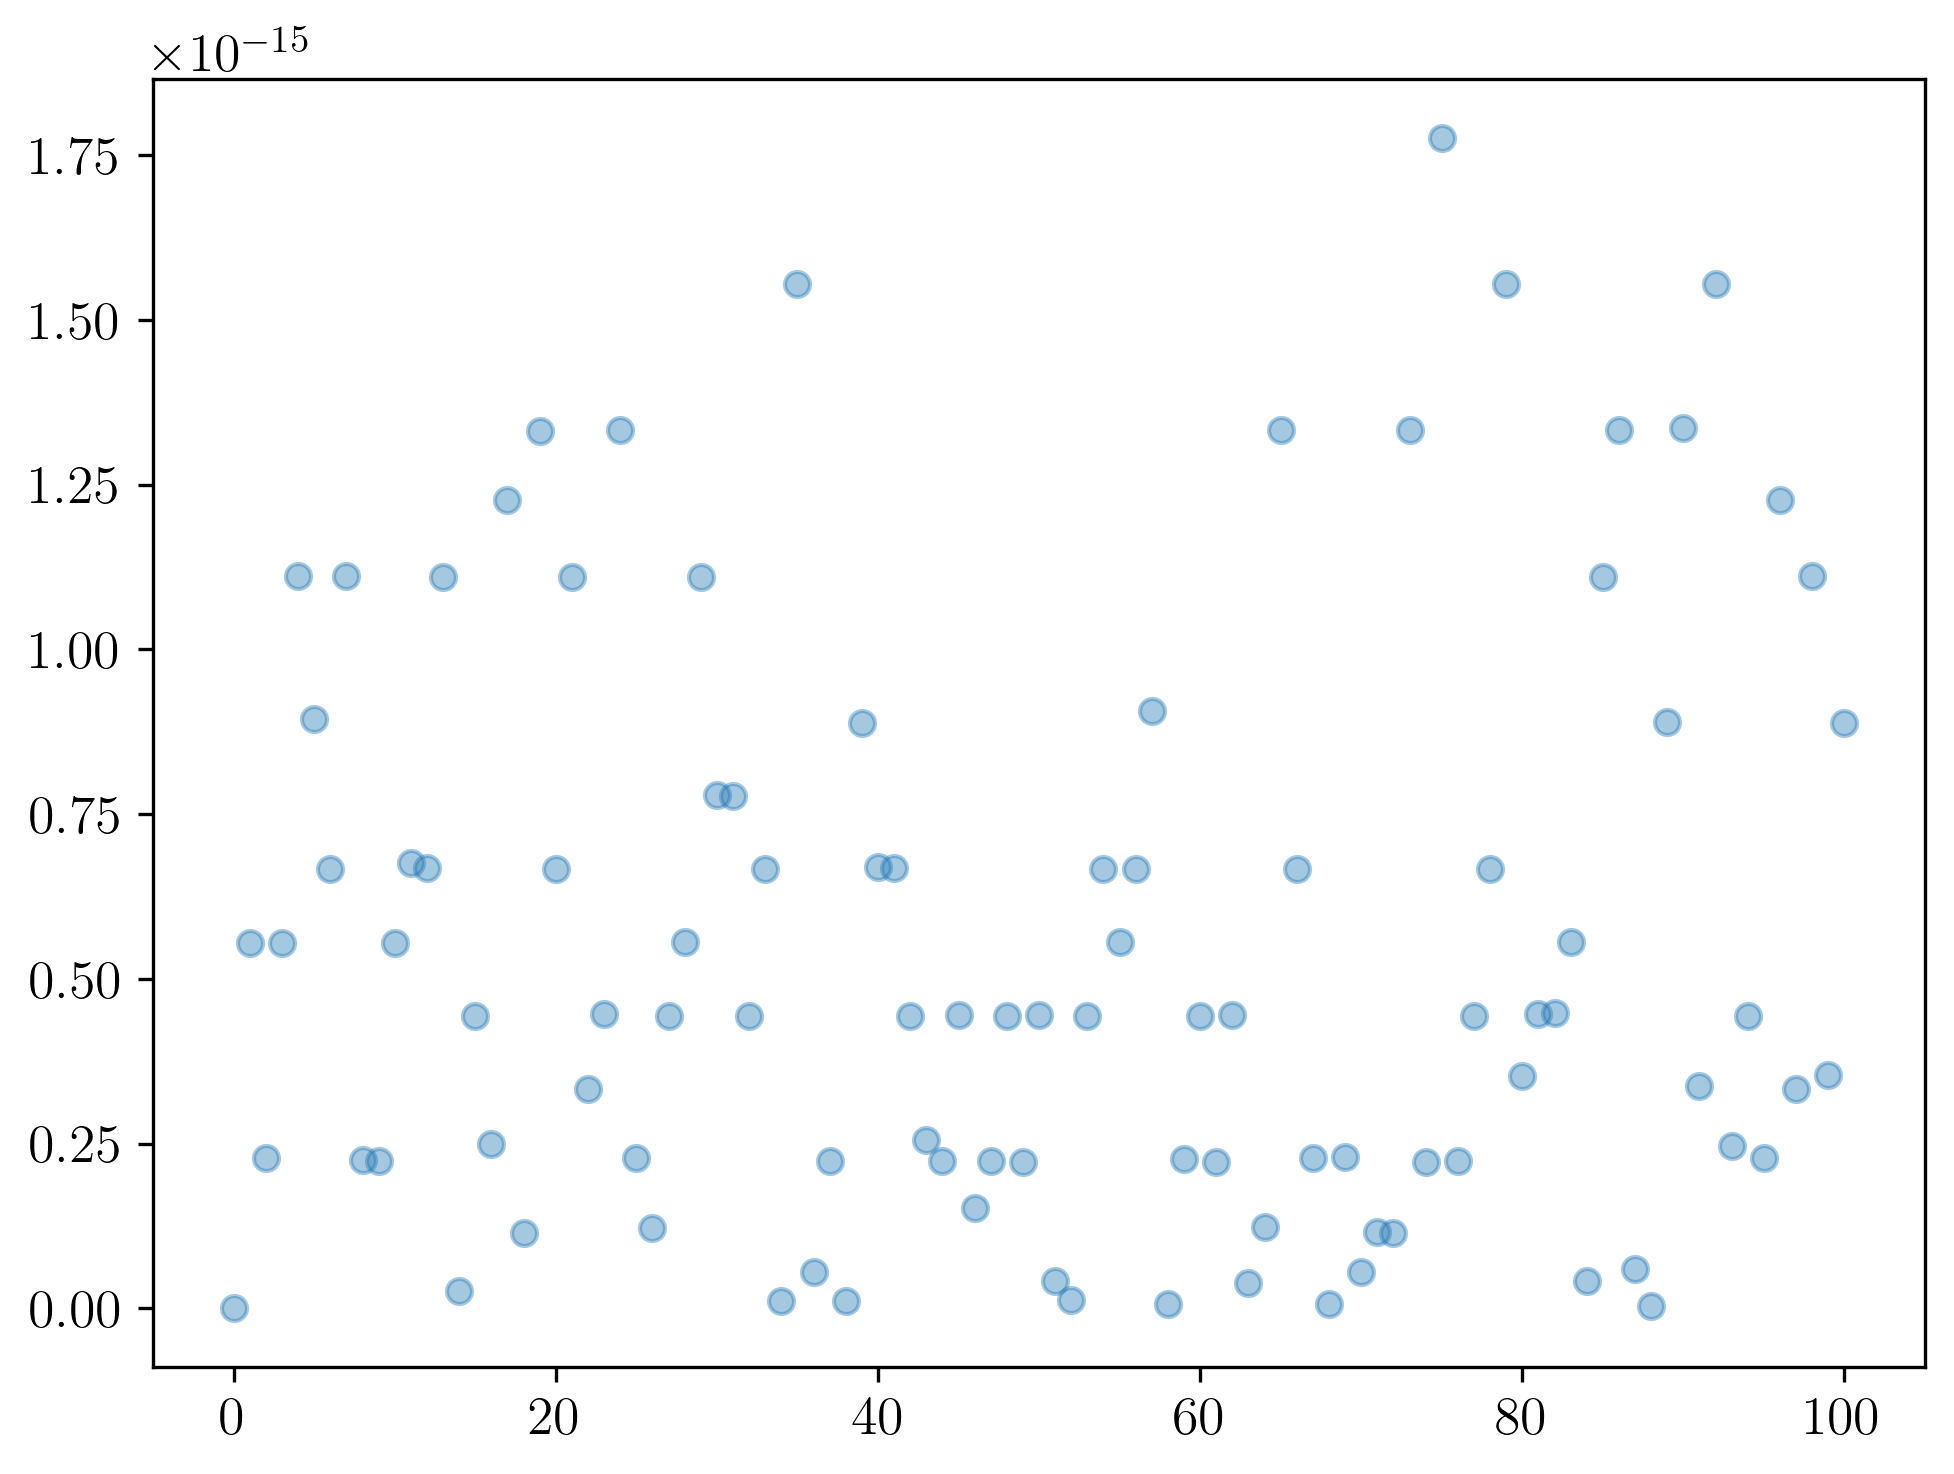

In [45]:
plt.plot(errs, 'o', alpha=0.4)

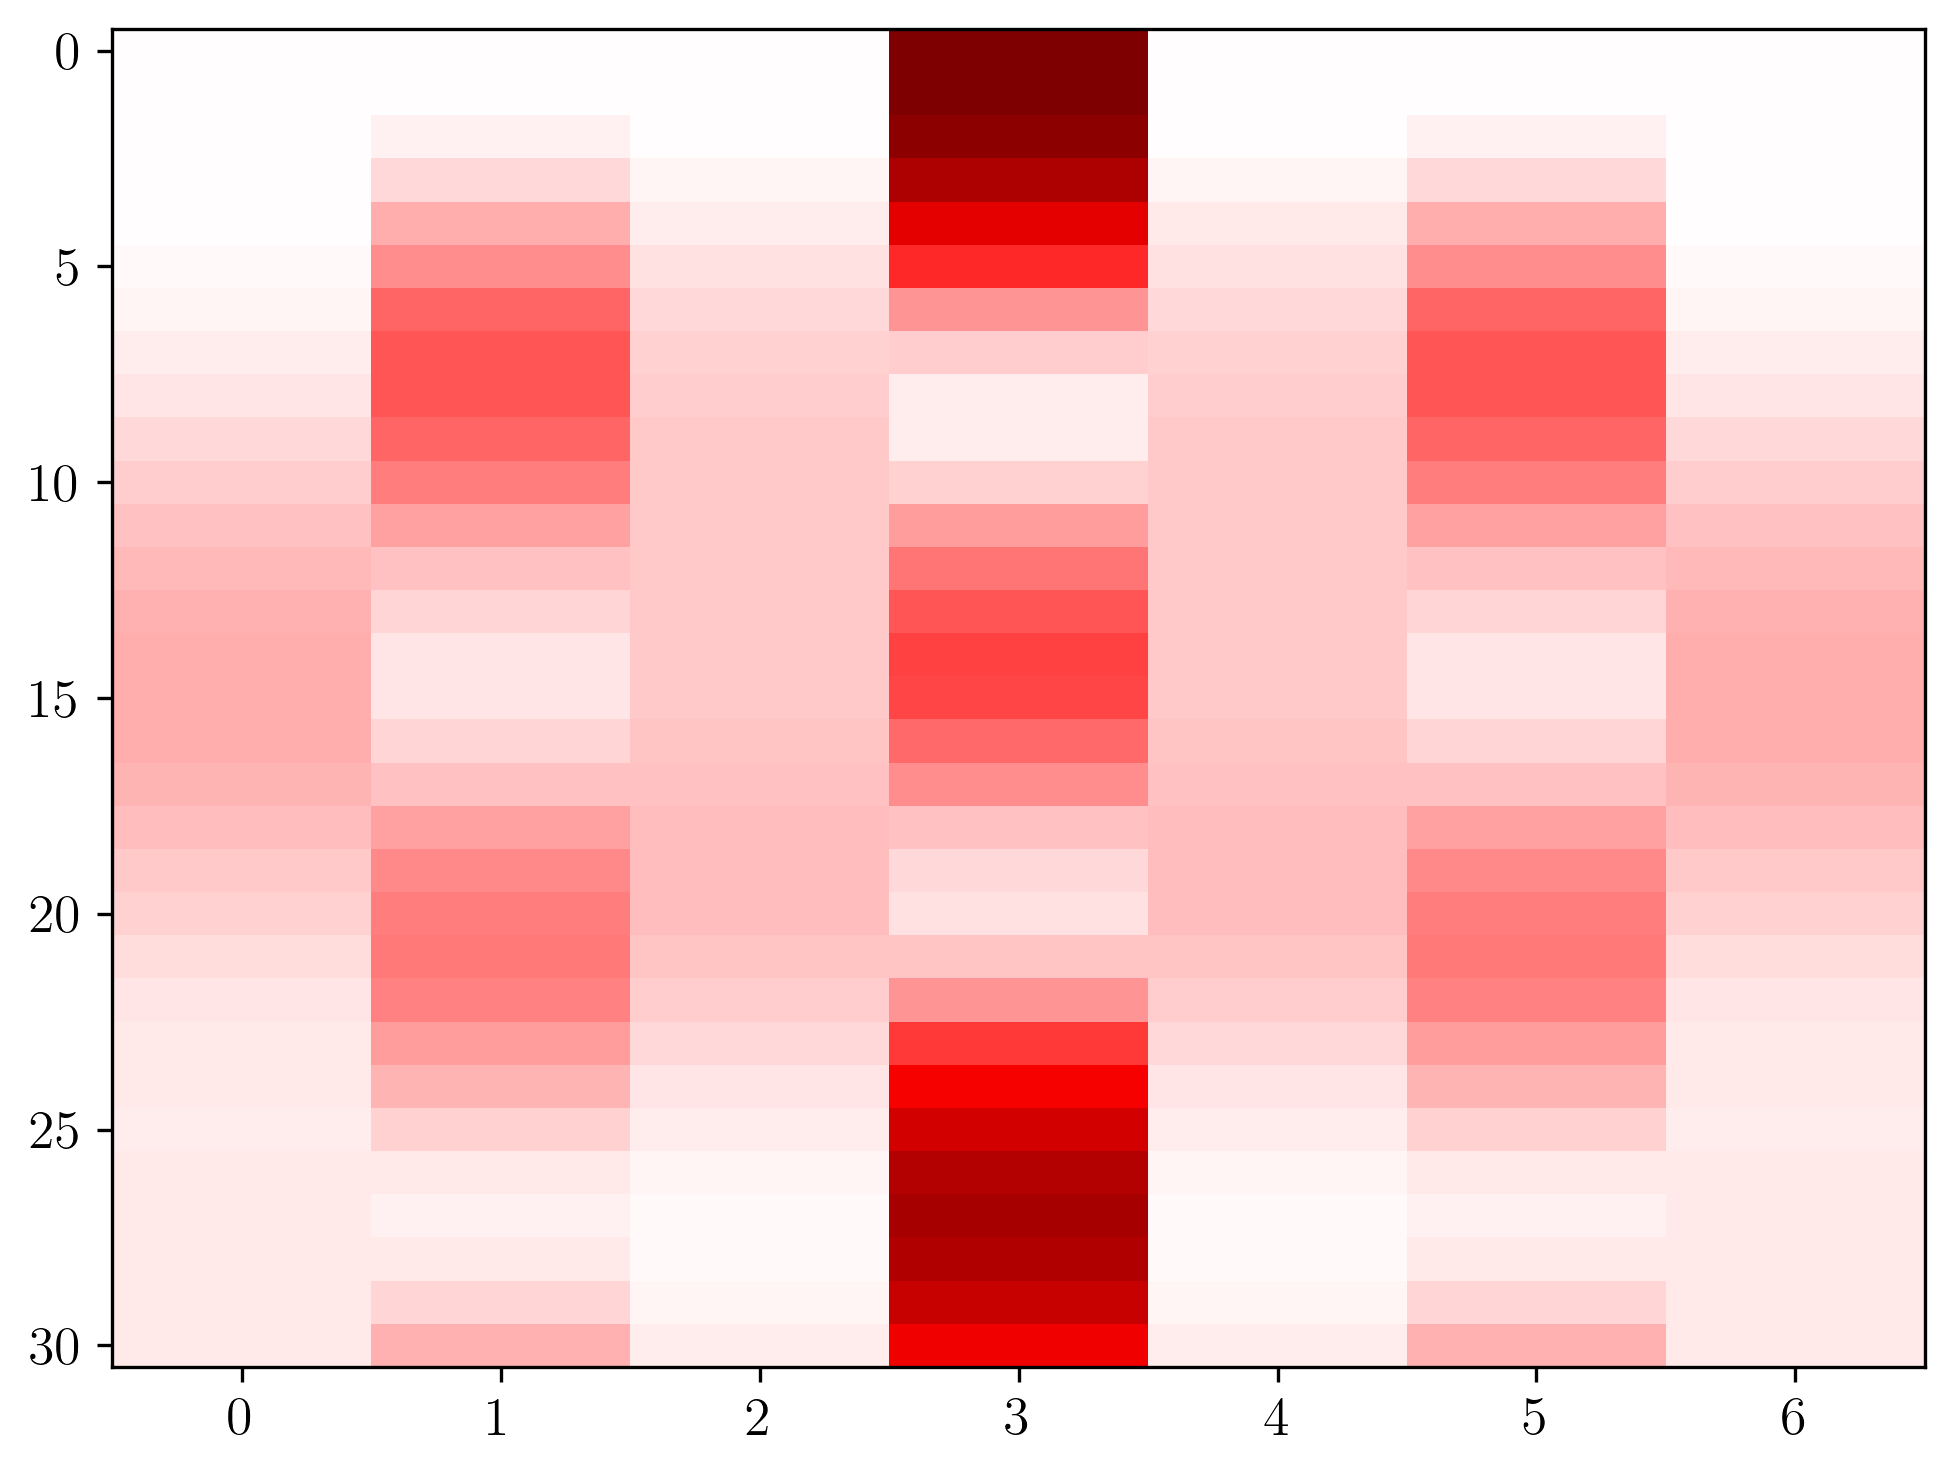

In [46]:
plt.imshow(np.asarray(local_magnetization), vmin=-1, vmax=1, aspect='auto', cmap='seismic')

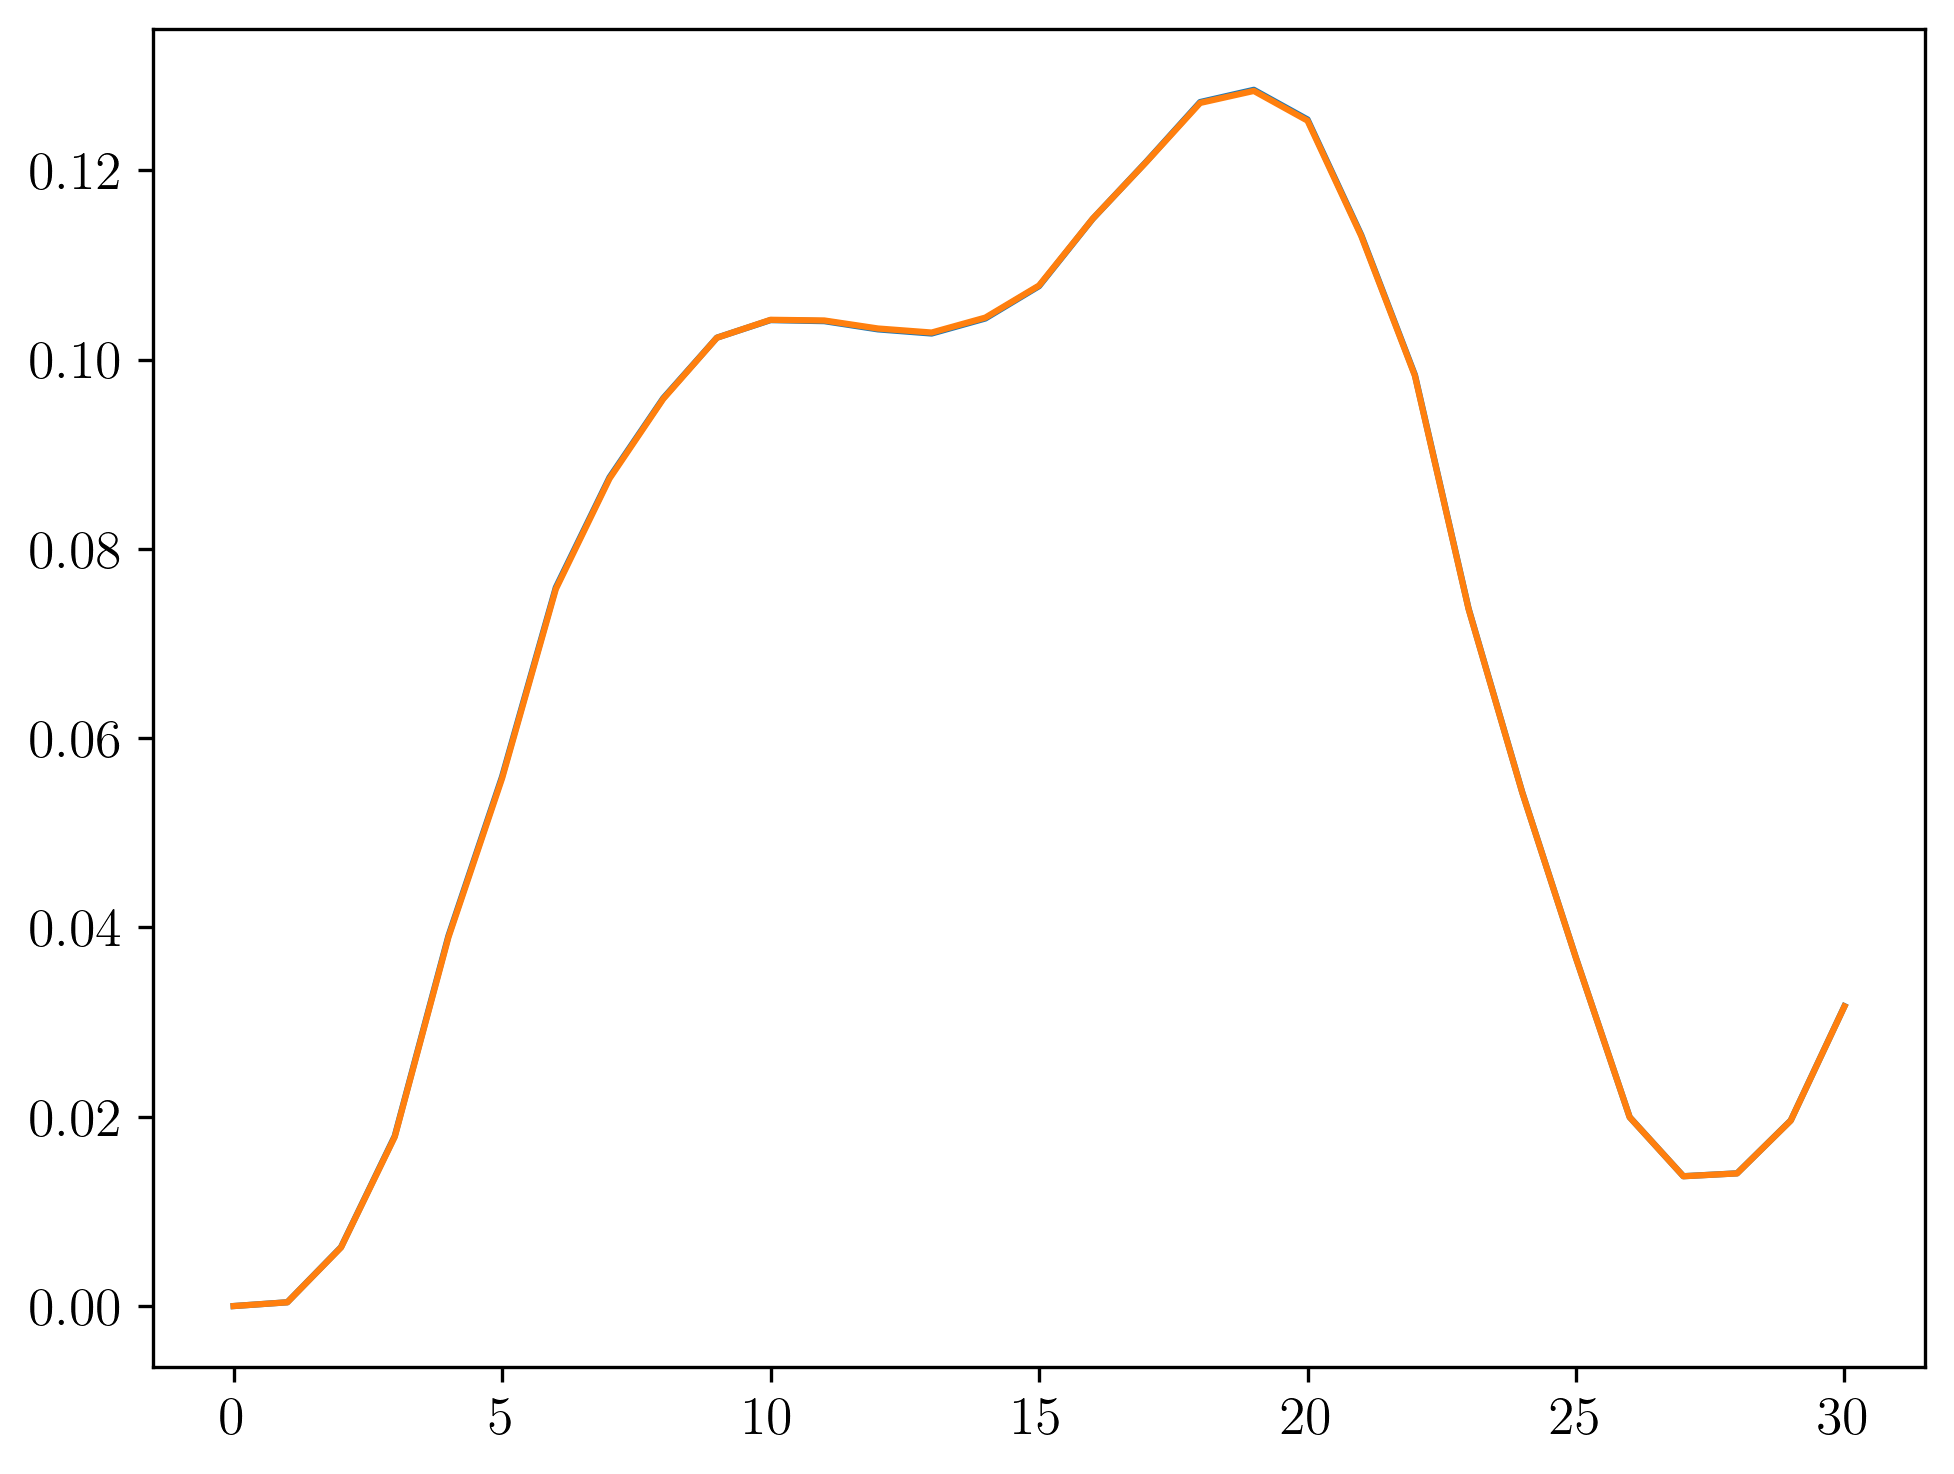

In [47]:
plt.plot(np.asarray(local_magnetization)[:,L//2+1])
plt.plot(np.asarray(local_magnetization)[:,L//2-1])

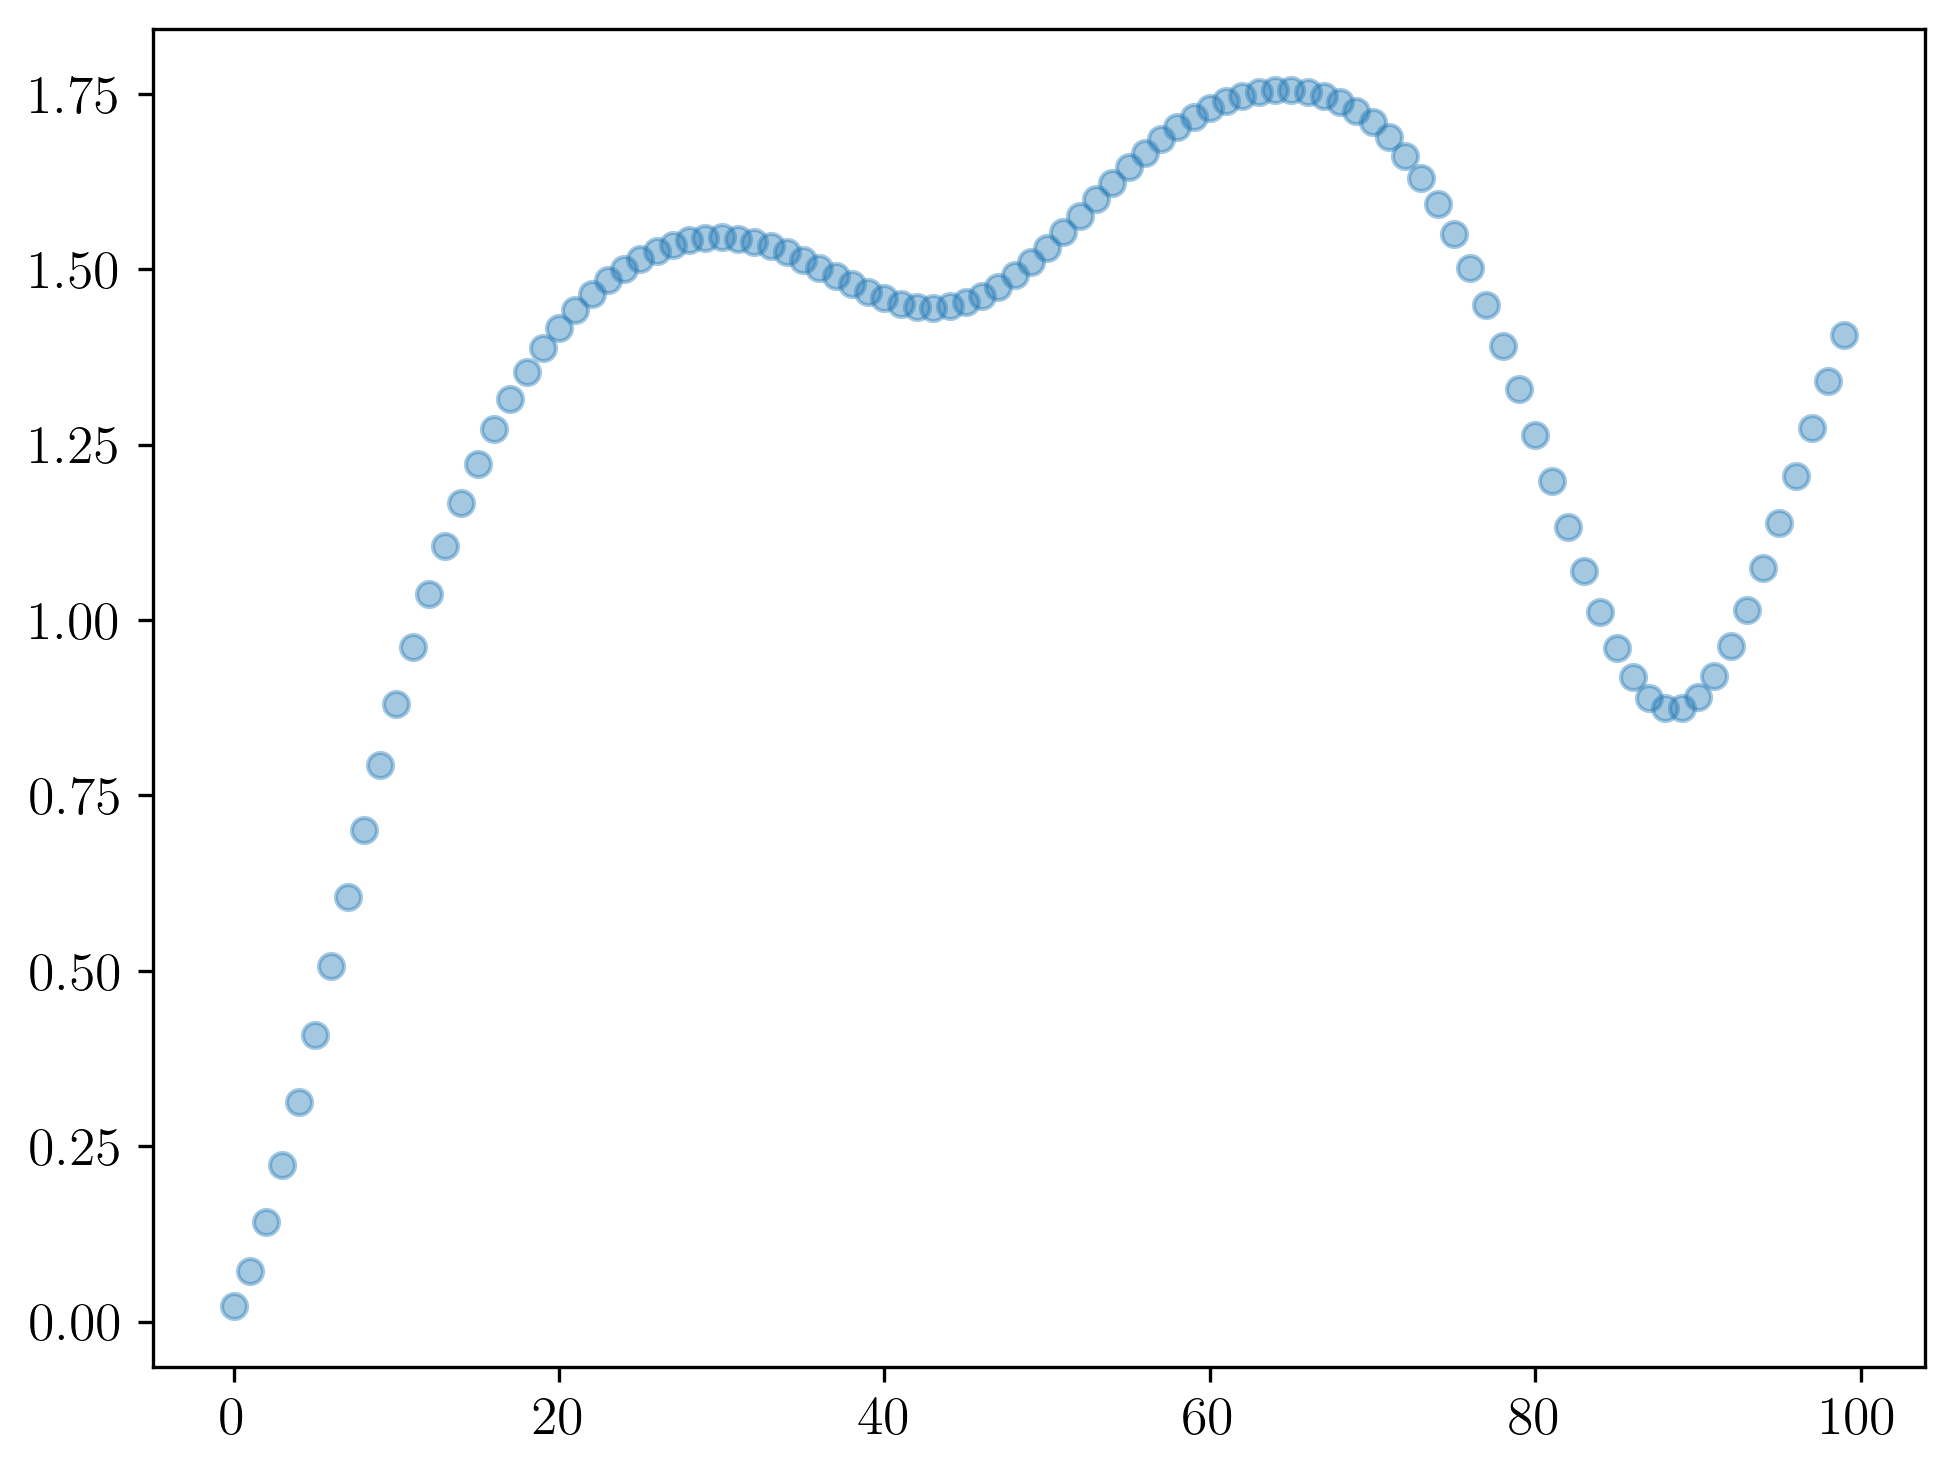

In [48]:
plt.plot(np.asarray(entrs)[:,0,0], 'o', alpha=0.4)

In [49]:
def evol(chis):
    mps_chain = MPS(L=L, d=3, model='tj', chi=1)
    # init_state = [hole_tn]*(L//2 - 1) + [spin_up_tn]*2 + [hole_tn]*(L//2 - 1)
    neel_state = neel_prod_state(half_chain_length)
    init_state = neel_state + [hole_tn] + [hole_tn] + neel_state
    mps_chain.sites = init_state.copy()

    # mpo_i_ip1 = mpo_ev_trotter_i_ip1_pipeline(L, Jz, J_perp, t_up, t_down, V, delta)
    mpo_i_ip1_eo, mpo_i_ip1_oe = mpo_ev_trotter_i_ip1_pipeline(L, Jz, J_perp, t_up, t_down, V, delta)
    mpo_i_ip2_delta_half, mpo_i_ip2_delta = mpo_ev_trotter_i_ip2_pipeline(L, tp_up, tp_down, delta)
    # tensor_shapes(mpo_i_ip1)
    tensor_shapes(mpo_i_ip2_delta_half)
    tensor_shapes(mpo_i_ip2_delta)
    mps_chain.w_dag = [mpo_i_ip1_eo.copy(), mpo_i_ip2_delta_half.copy(), mpo_i_ip2_delta.copy(), mpo_i_ip2_delta_half.copy(), mpo_i_ip1_oe.copy()]
    # mps_chain.w_dag = [mpo_i_ip1.copy(), mpo_i_ip2_delta_half.copy(), mpo_i_ip2_delta.copy(), mpo_i_ip2_delta_half.copy()]
    # mps_chain.w_dag = [mpo_i_ip1.copy()]

    errs_chi, entrs_chi, loc_mag_chi, svs_chi = [], [], [], []
    for chi in chis:
        print("--------------")
        print(f"chi: {chi}")
        print("--------------")
        (
        errs,
        entrs,
        svs,
        local_magnetization,
        ovlps,
        chi_sat,
                ) = mps_chain.TEBD_variational_tJ(trotter_steps=trotter_steps, where=mps_chain.L//2, chi_max=chi, obs=['lh'], obs_freq=1)
        
        errs_chi.append(errs)
        entrs_chi.append(entrs)
        loc_mag_chi.append(local_magnetization)
        svs_chi.append(svs)
        
        mps_chain.sites = init_state.copy()

    return errs_chi, entrs_chi, loc_mag_chi, svs_chi


In [51]:
half_chain_length = 5
L = 2*half_chain_length + 2
t_up = 1
t_down = 1
t_up = 16
t_down = 16
Jz = 10
J_perp = 1
eps = 0
V = 0
trotter_steps = 100
final_time = 2
delta = final_time / trotter_steps

In [52]:
err, entr, loc, svs = evol([60,80,100,120])

(1, 9, 3, 3)
(9, 81, 3, 3)
(81, 9, 3, 3)
(9, 1, 3, 3)
(1, 9, 3, 3)
(9, 81, 3, 3)
(81, 9, 3, 3)
(9, 1, 3, 3)
(1, 9, 3, 3)
(9, 81, 3, 3)
(81, 9, 3, 3)
(9, 1, 3, 3)
(1, 1, 3, 3)
(1, 1, 3, 3)
(1, 9, 3, 3)
(9, 81, 3, 3)
(81, 9, 3, 3)
(9, 1, 3, 3)
(1, 9, 3, 3)
(9, 81, 3, 3)
(81, 9, 3, 3)
(9, 1, 3, 3)
(1, 1, 3, 3)
(1, 1, 3, 3)
--------------
chi: 60
--------------


C:\Users\HP\Desktop\qs-mps\src\qs_mps\mps_class.py:1824: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  operator = diags([0, 1, 0], 0, format="csr").toarray()


trotter_step: 0


i,i+2 interaction delta/2: 100%|██████████| 5/5 [00:10<00:00,  2.19s/it]


trotter_step: 1


...

trotter_step: 24


i,i+2 interaction delta/2: 100%|██████████| 5/5 [00:12<00:00,  2.52s/it]


trotter_step: 25


i,i+2 interaction delta:  40%|████      | 2/5 [00:05<00:08,  2.69s/it]  


KeyboardInterrupt: 

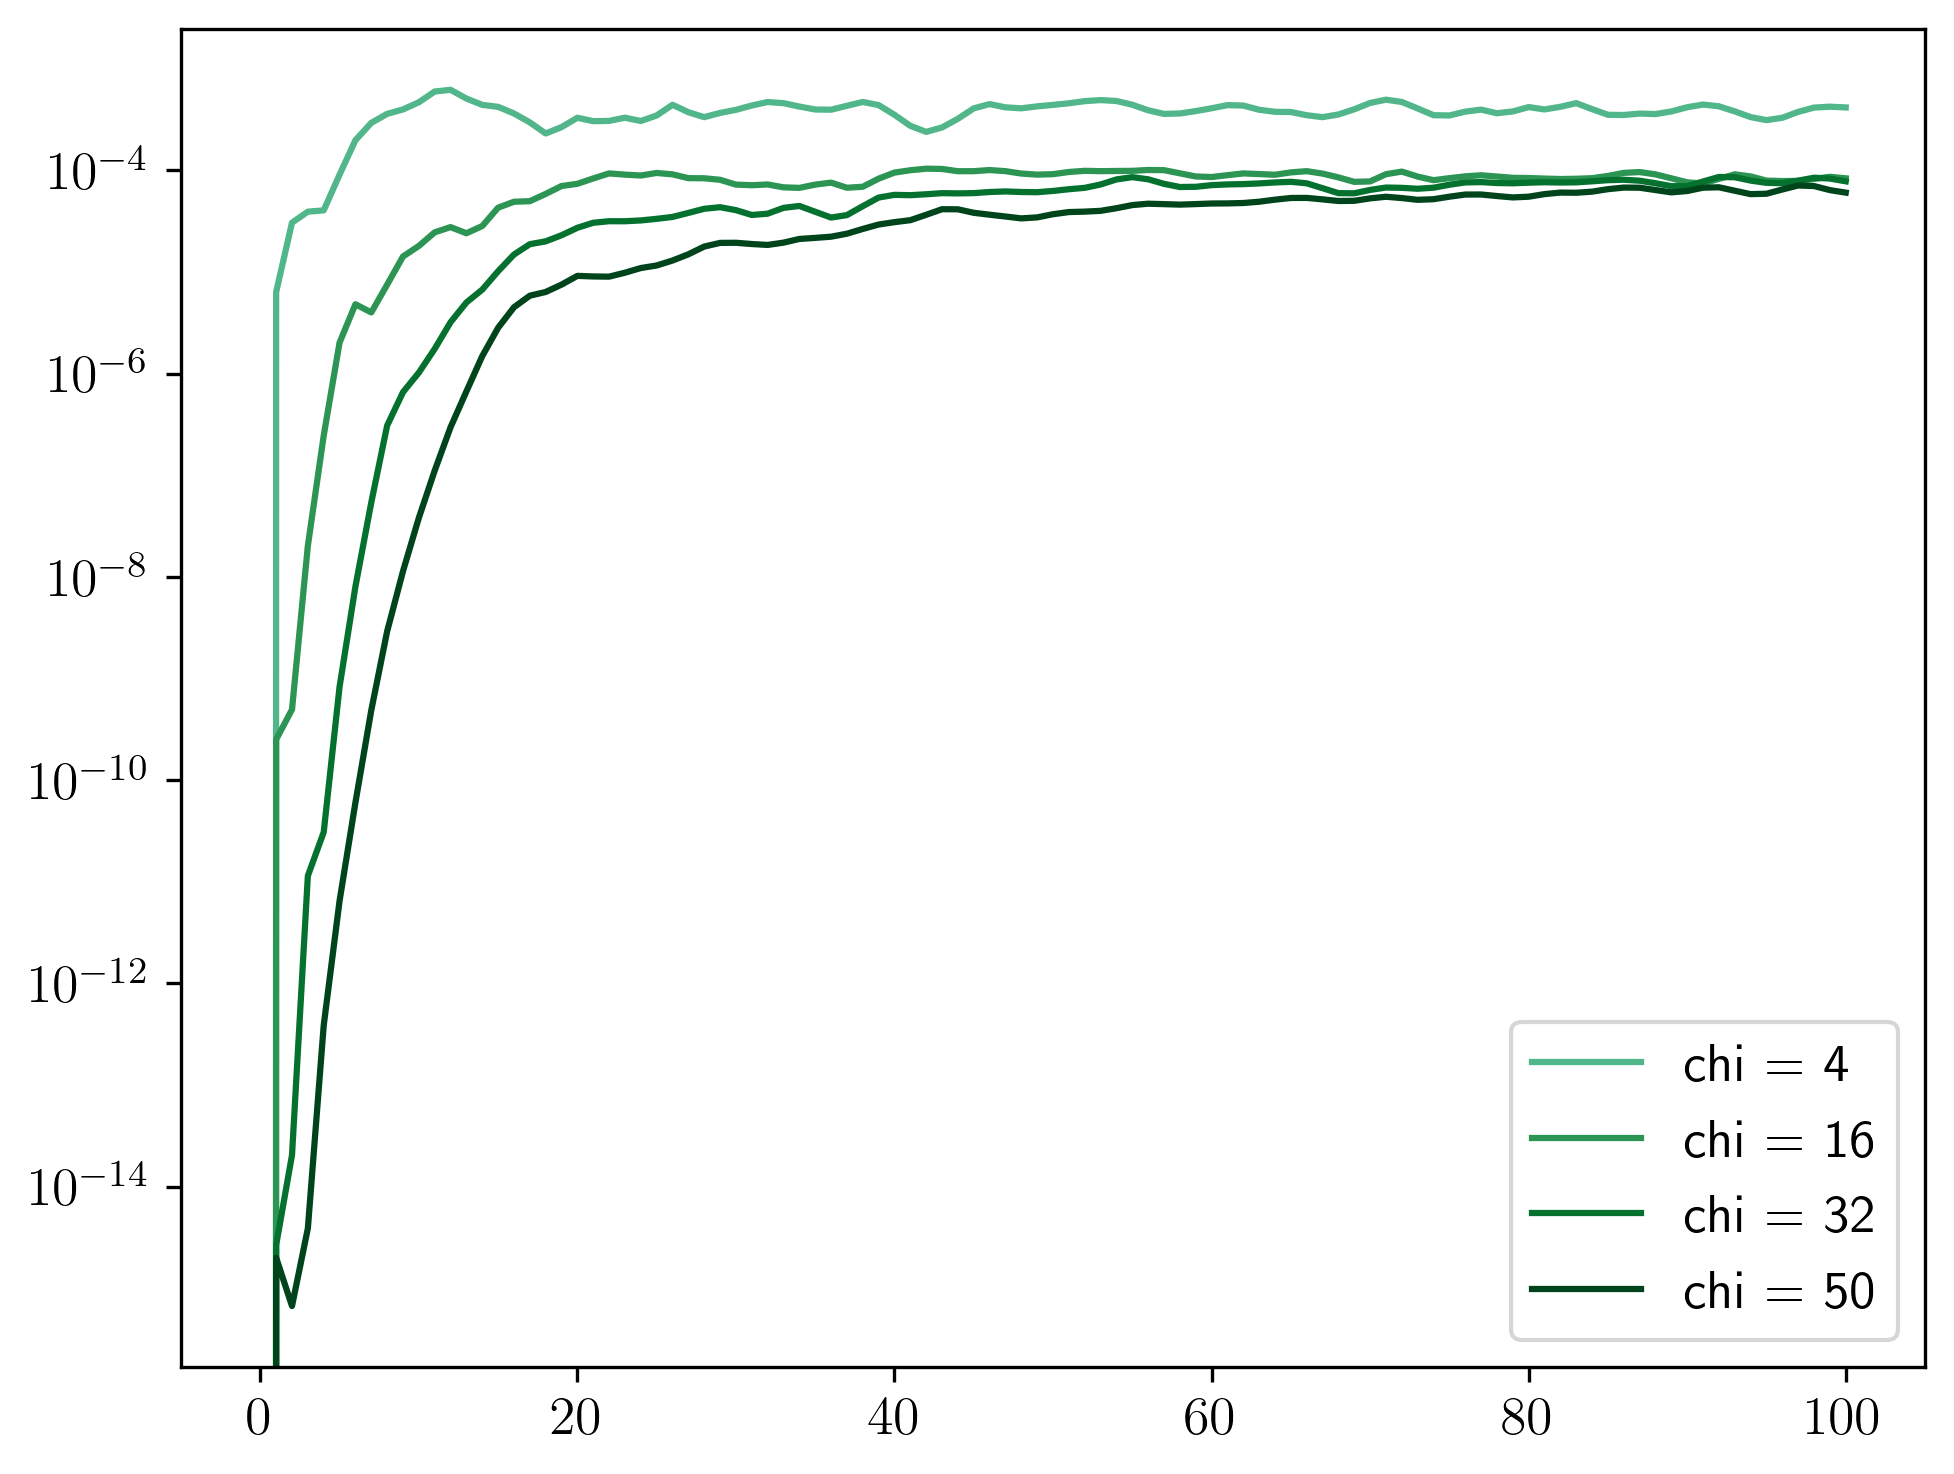

In [ ]:
from qs_mps.utils import create_sequential_colors
chis = [60,80,100,120]
colors = create_sequential_colors(2*len(chis), "BuGn")

for i, er in enumerate(err):
    plt.plot(er, color=colors[len(chis)+i], label=f"chi = {chis[i]}")

plt.yscale('log')
plt.legend()

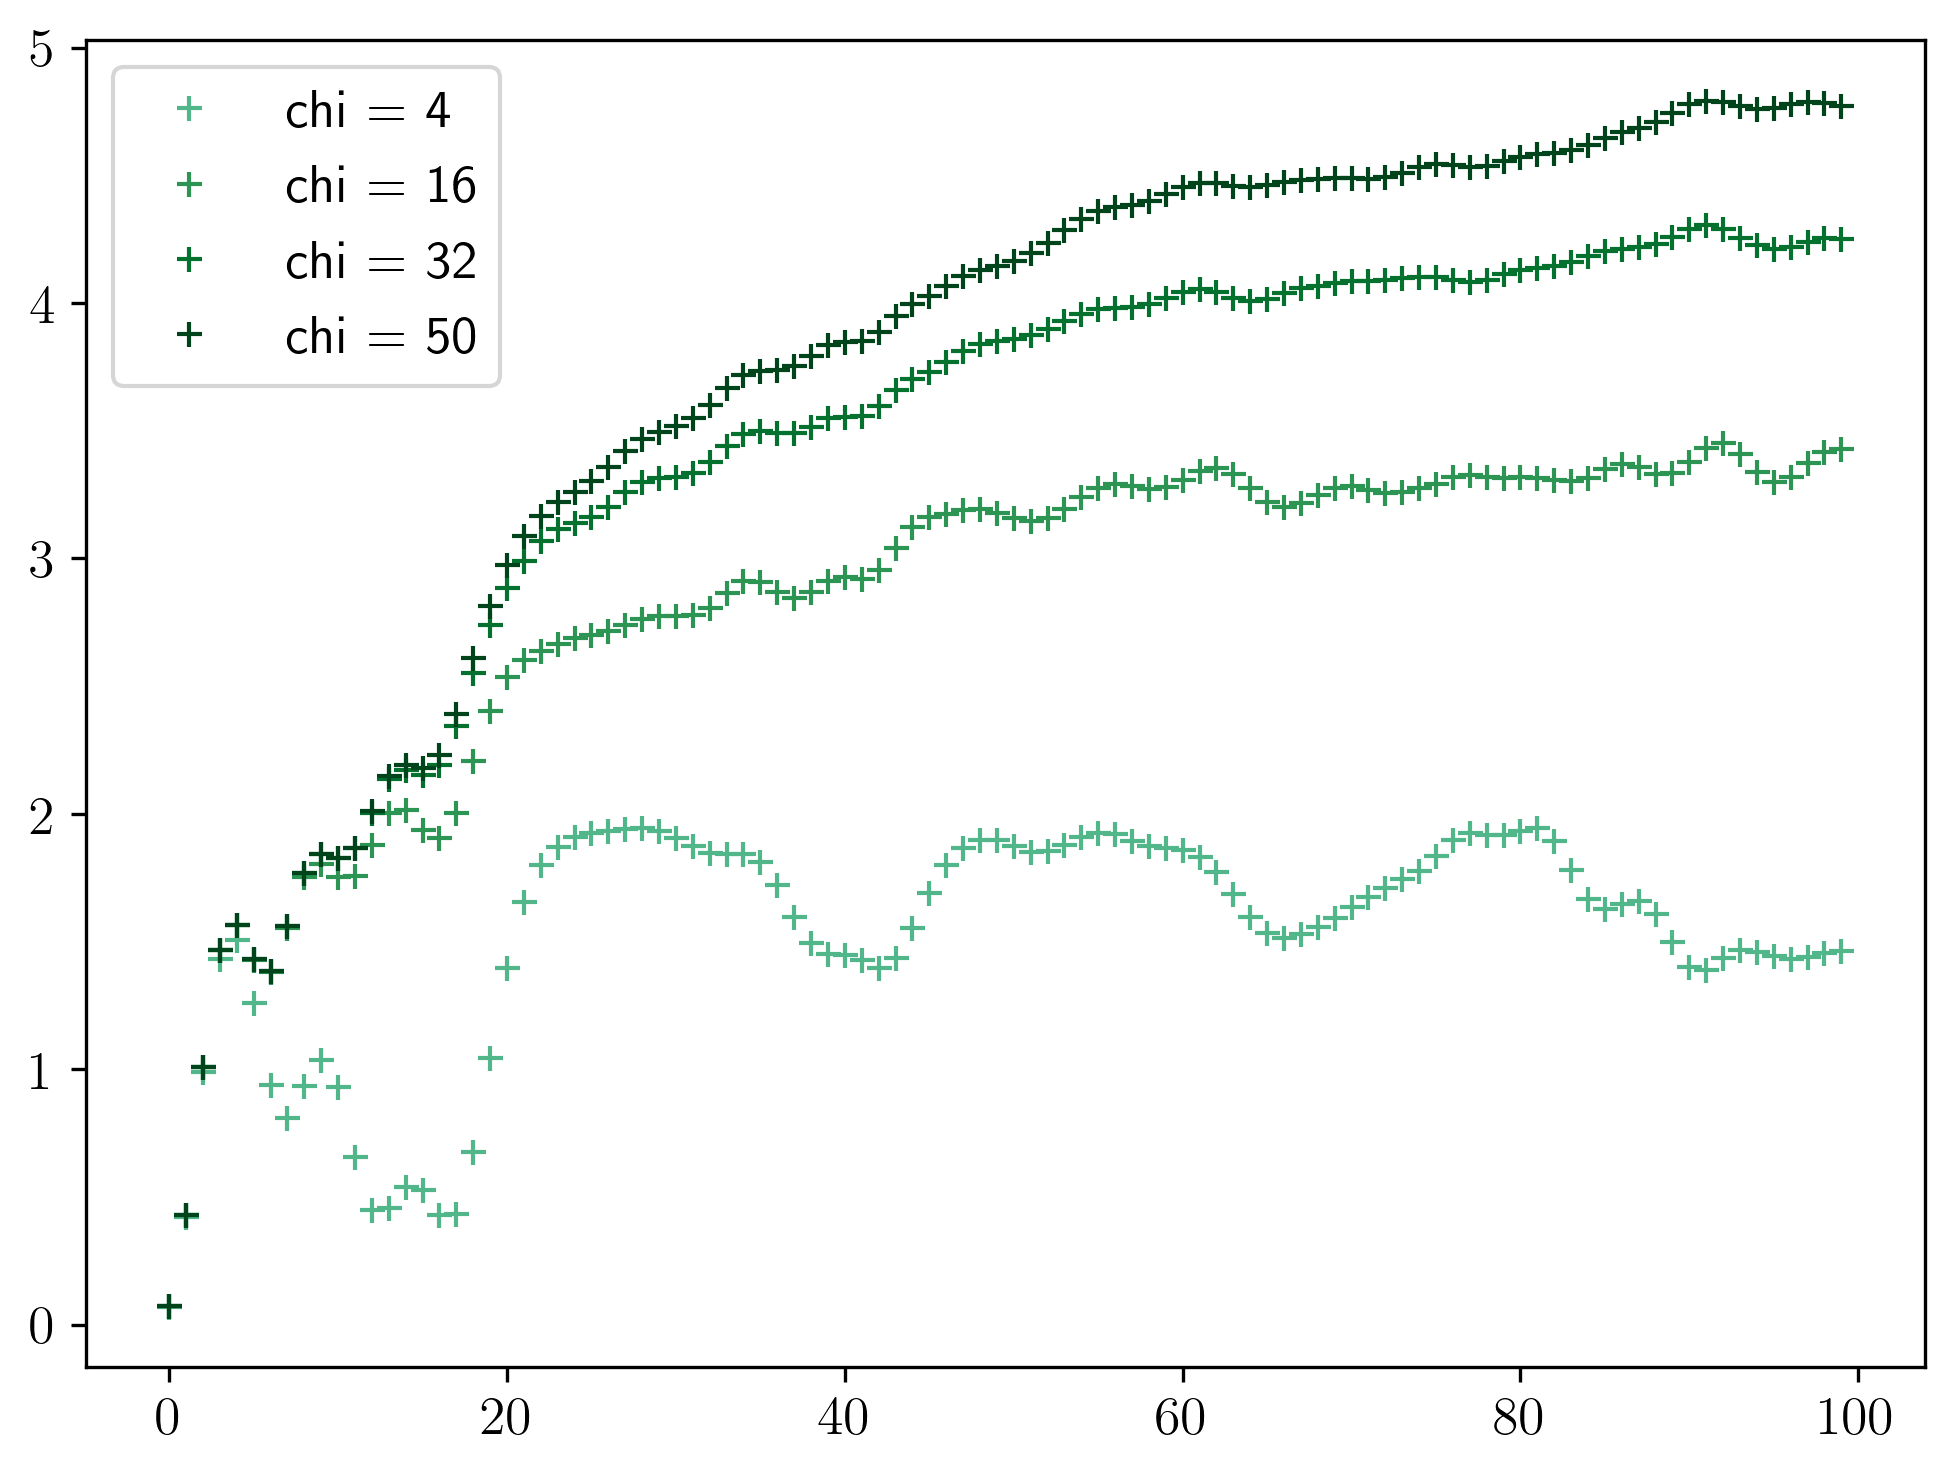

In [ ]:
for i, ent in enumerate(entr):
    plt.plot(np.asarray(ent)[:,0,0], '+', alpha=1, color=colors[len(chis)+i], label=f"chi = {chis[i]}")

# plt.yscale('log')
plt.legend()

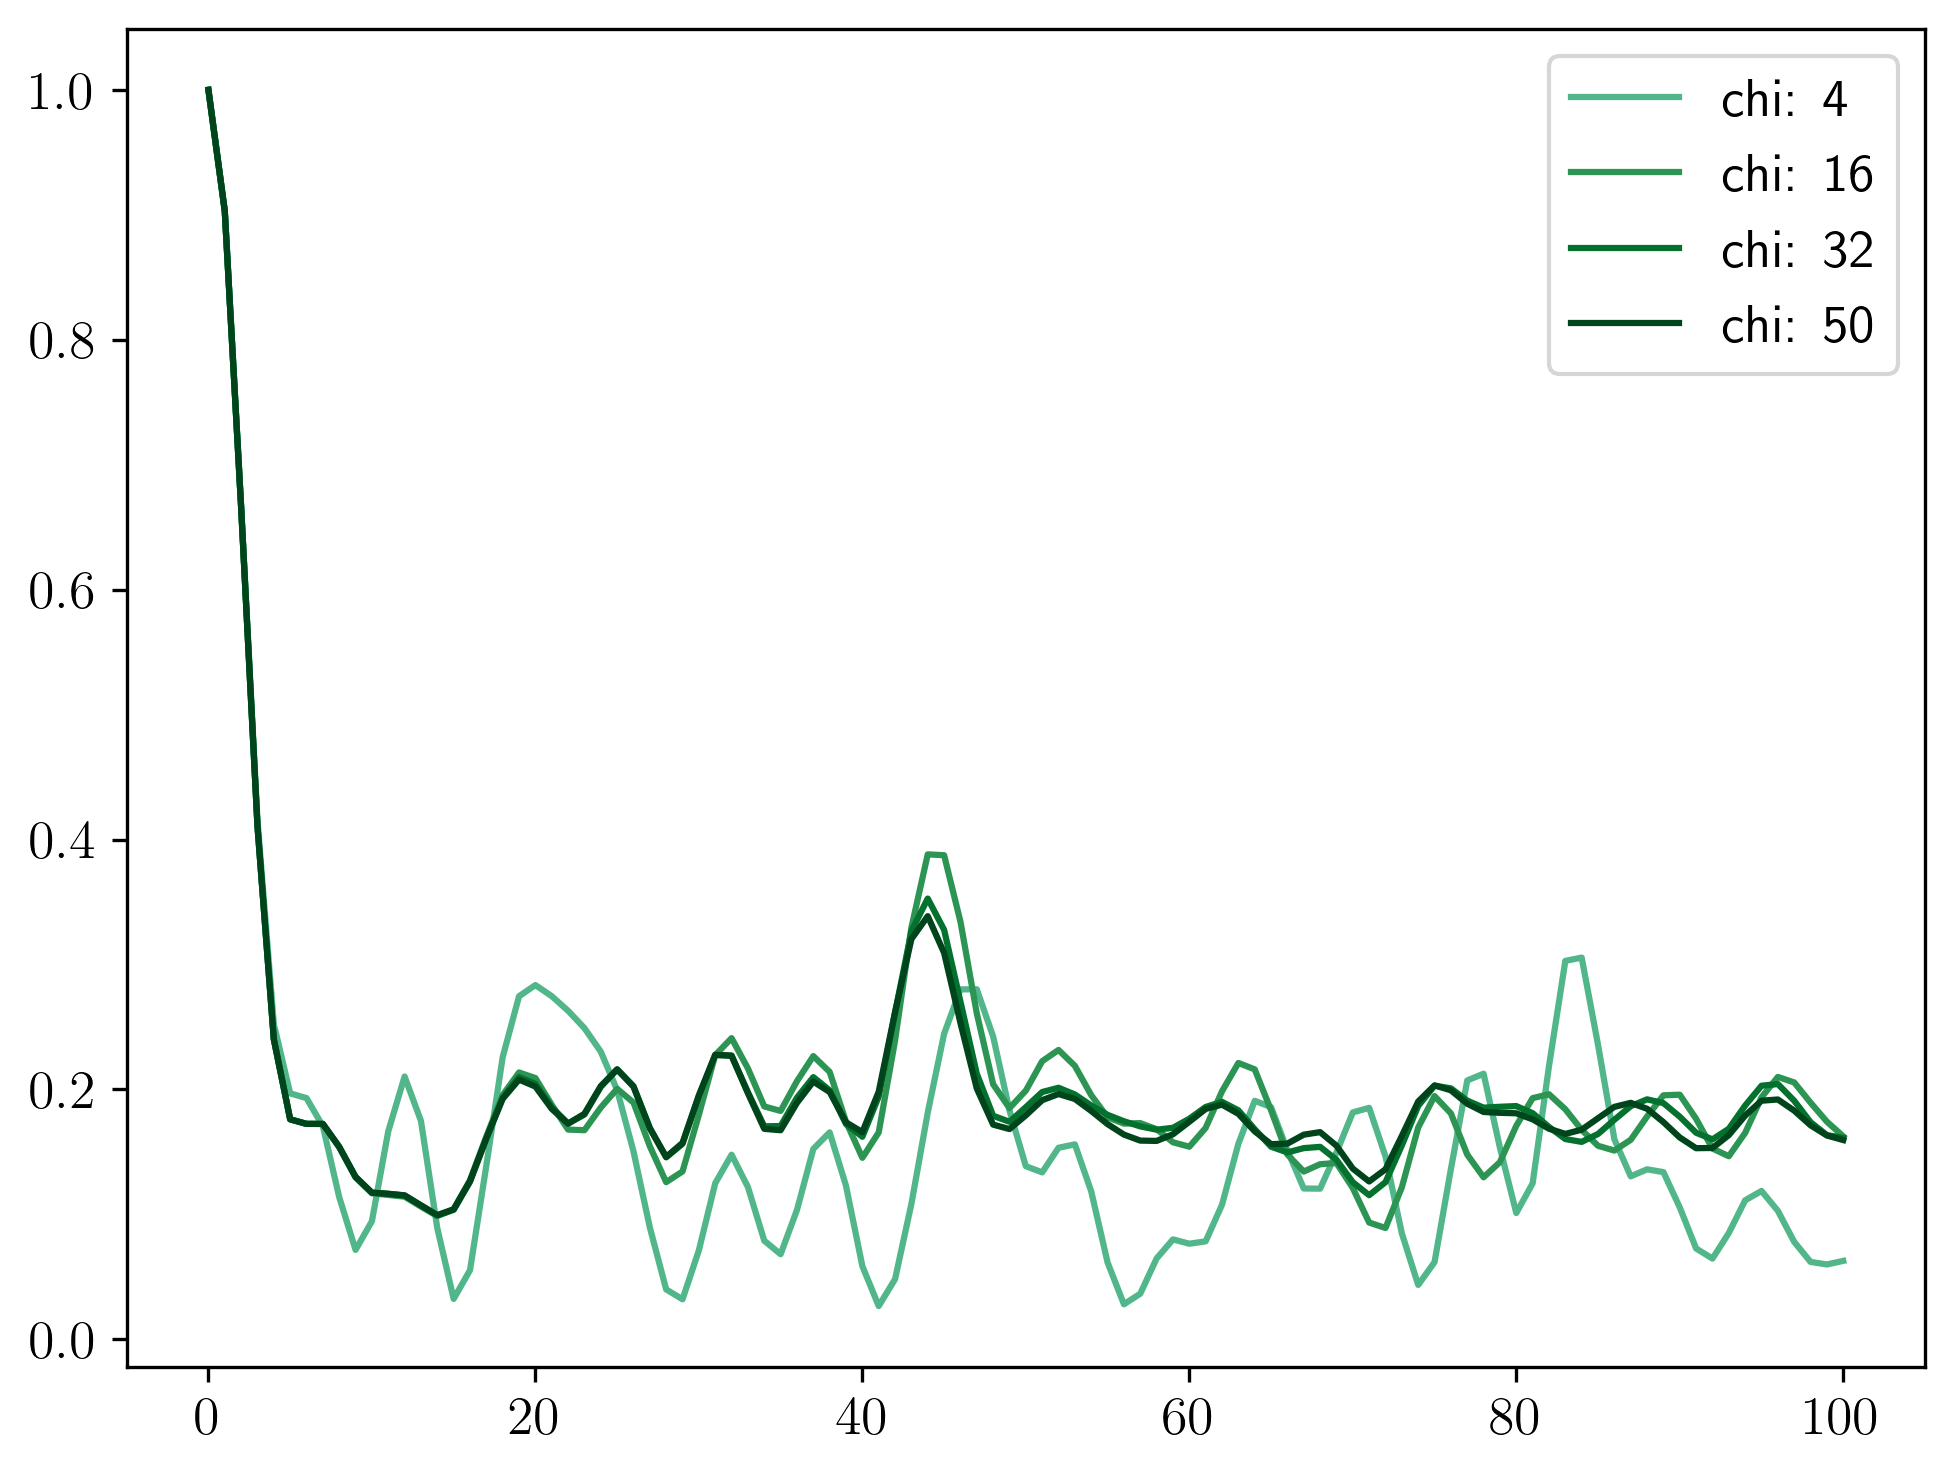

In [ ]:
for i, local_magnetization in enumerate(loc):
    plt.plot(np.asarray(local_magnetization)[:,L//2], color=colors[len(chis)+i], label=f"chi: {chis[i]}")

plt.legend()

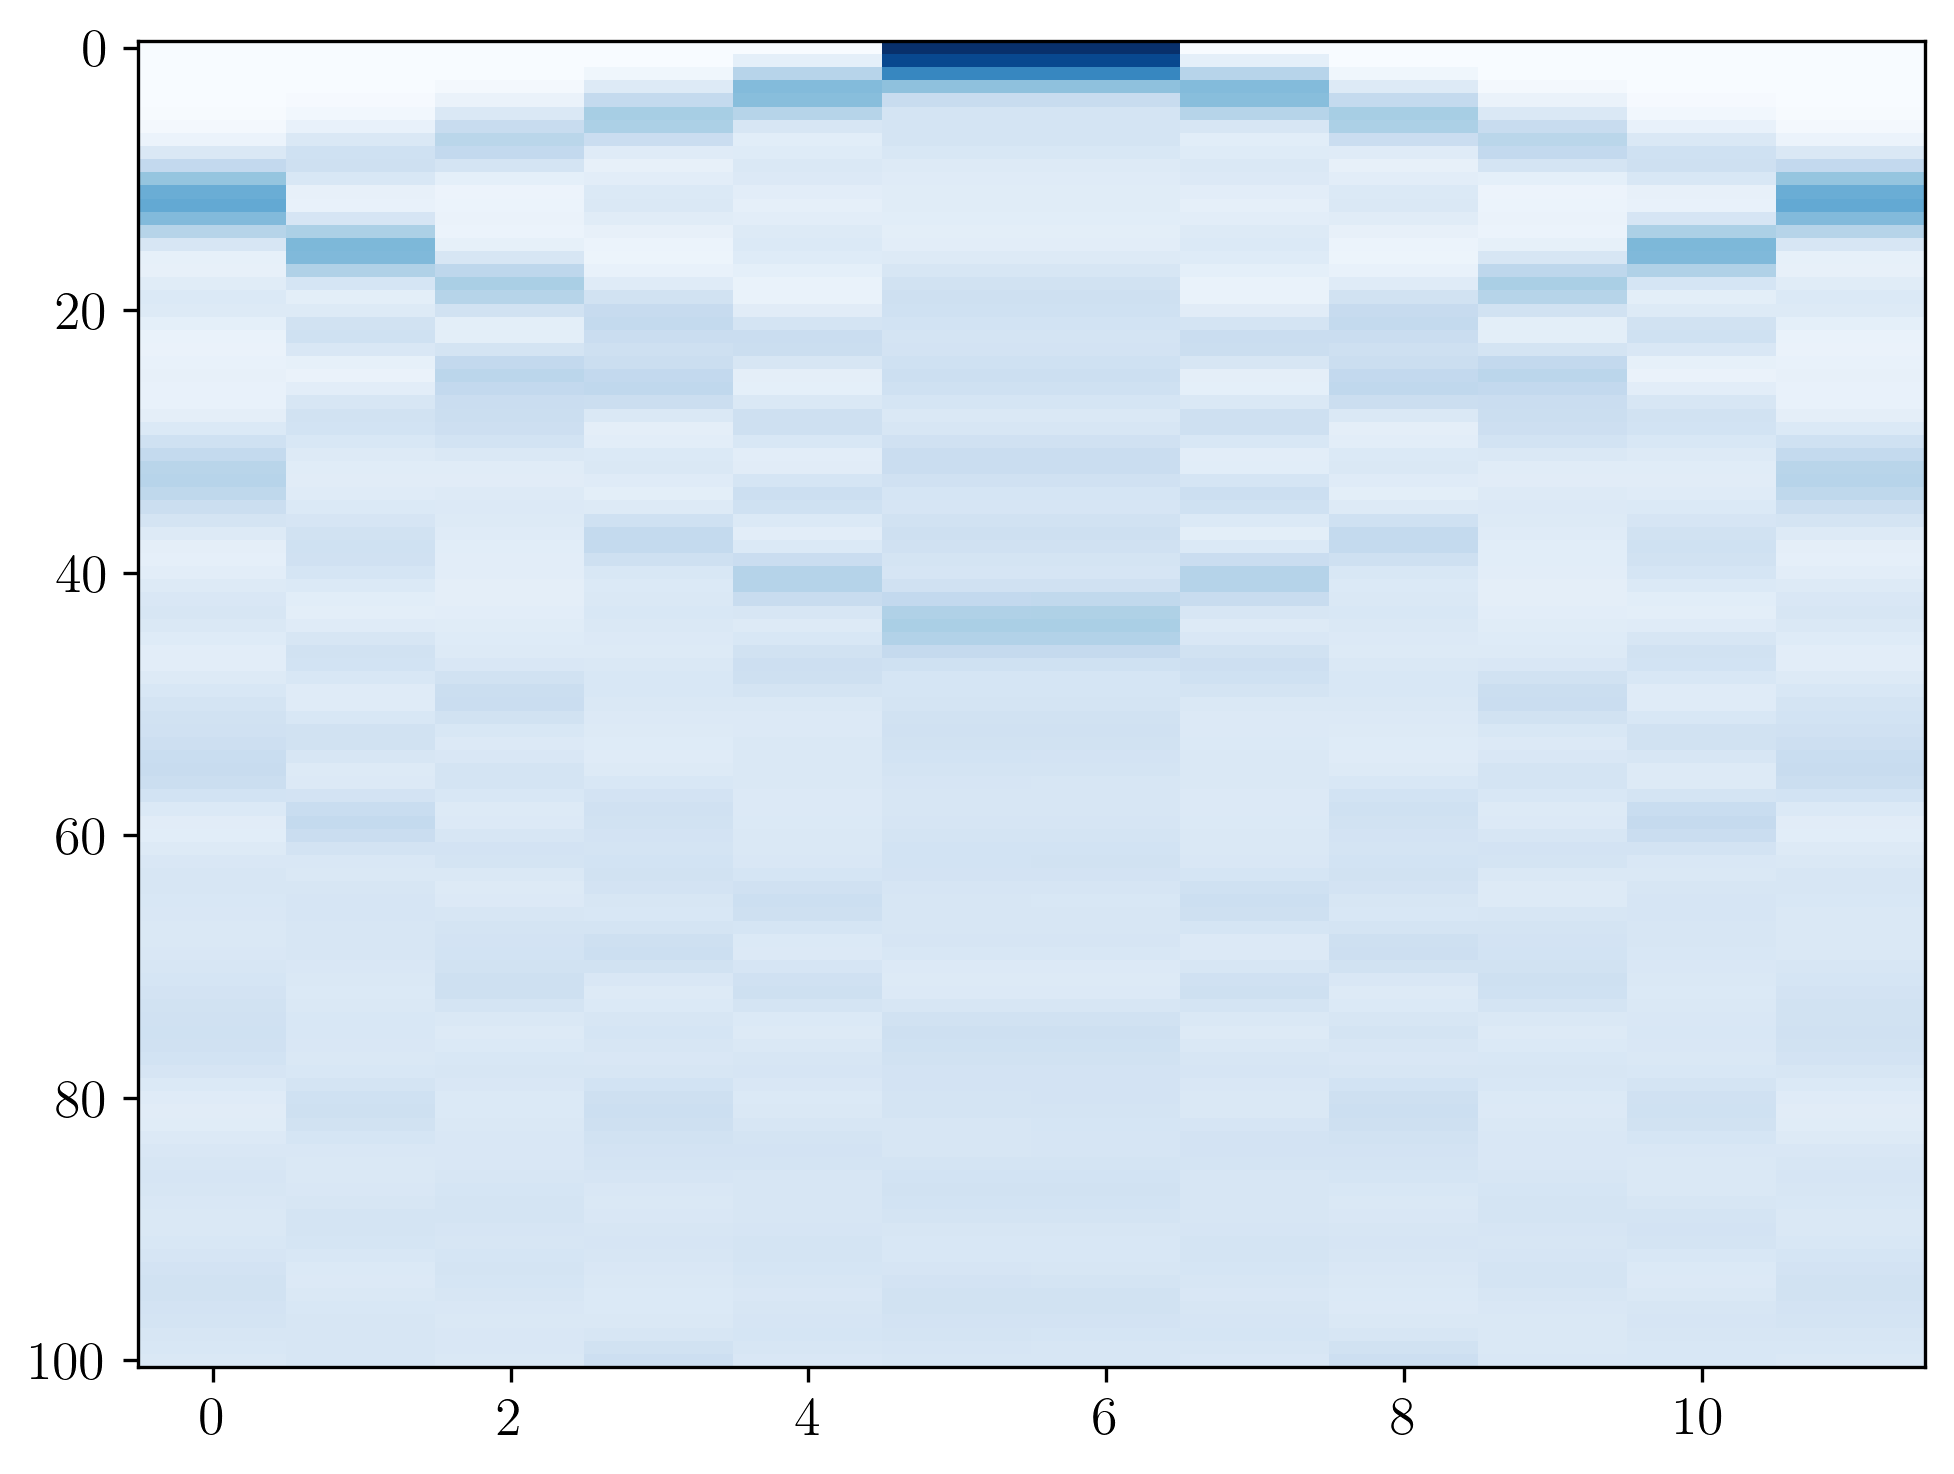

In [ ]:
plt.imshow(np.asarray(loc)[-1], vmin=0, vmax=1, aspect='auto', cmap='Blues')

In [ ]:
spin_up = np.array([1,0,0])
hole = np.array([0,1,0])
spin_down = np.array([0,0,1])

H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, tp_up=tp_up, tp_down=tp_down, n_holes=2)

# psi_init = kron(spin_up, kron(spin_down, kron(spin_up, kron(hole, kron(hole, kron(spin_up, kron(spin_down, spin_up))))))).T.toarray()
# psi_init = kron(spin_down, kron(spin_up, kron(spin_down, kron(hole, kron(hole, kron(spin_down, kron(spin_up, spin_down))))))).T.toarray()
# psi_init = kron(spin_up, kron(spin_down, kron(spin_up, kron(hole, kron(hole, kron(spin_down, kron(spin_up, spin_down))))))).T.toarray()
# psi_init = kron(spin_down, kron(spin_up, kron(spin_down, kron(hole, kron(hole, kron(spin_up, kron(spin_down, spin_up))))))).T.toarray()
# psi_init = kron(hole, kron(hole, kron(spin_up, kron(hole, hole)))).T.toarray()
# psi_init = kron(hole, kron(hole, kron(spin_up, kron(spin_up, kron(hole, hole))))).T.toarray()

psi_init = kron(hole, kron(hole, kron(hole, kron(hole, kron(hole, kron(spin_up, kron(spin_up, kron(hole, kron(hole, kron(hole, kron(hole, hole))))))))))).T.toarray()
psi_init = kron(spin_up, kron(spin_down, kron(spin_up, kron(spin_down, kron(spin_up, kron(hole, kron(hole, kron(spin_up, kron(spin_down, kron(spin_up, kron(spin_down, spin_up))))))))))).T.toarray()
# psi_init = psi_init.reshape((3**6))
psi_init = psi_init.reshape((3**(2*half_chain_length+2)))

# H_ev = tJV_ham(n=2*half_chain_length+2, t_up=t_up, t_down=t_down, Jz=Jz, J_perp=J_perp, eps=eps, V=V)
exp_vals, psi_save = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time, obs=['h_loc'], n_holes=2, save=False)

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

Text(0.5, 0, 'time $(\\delta T)$')

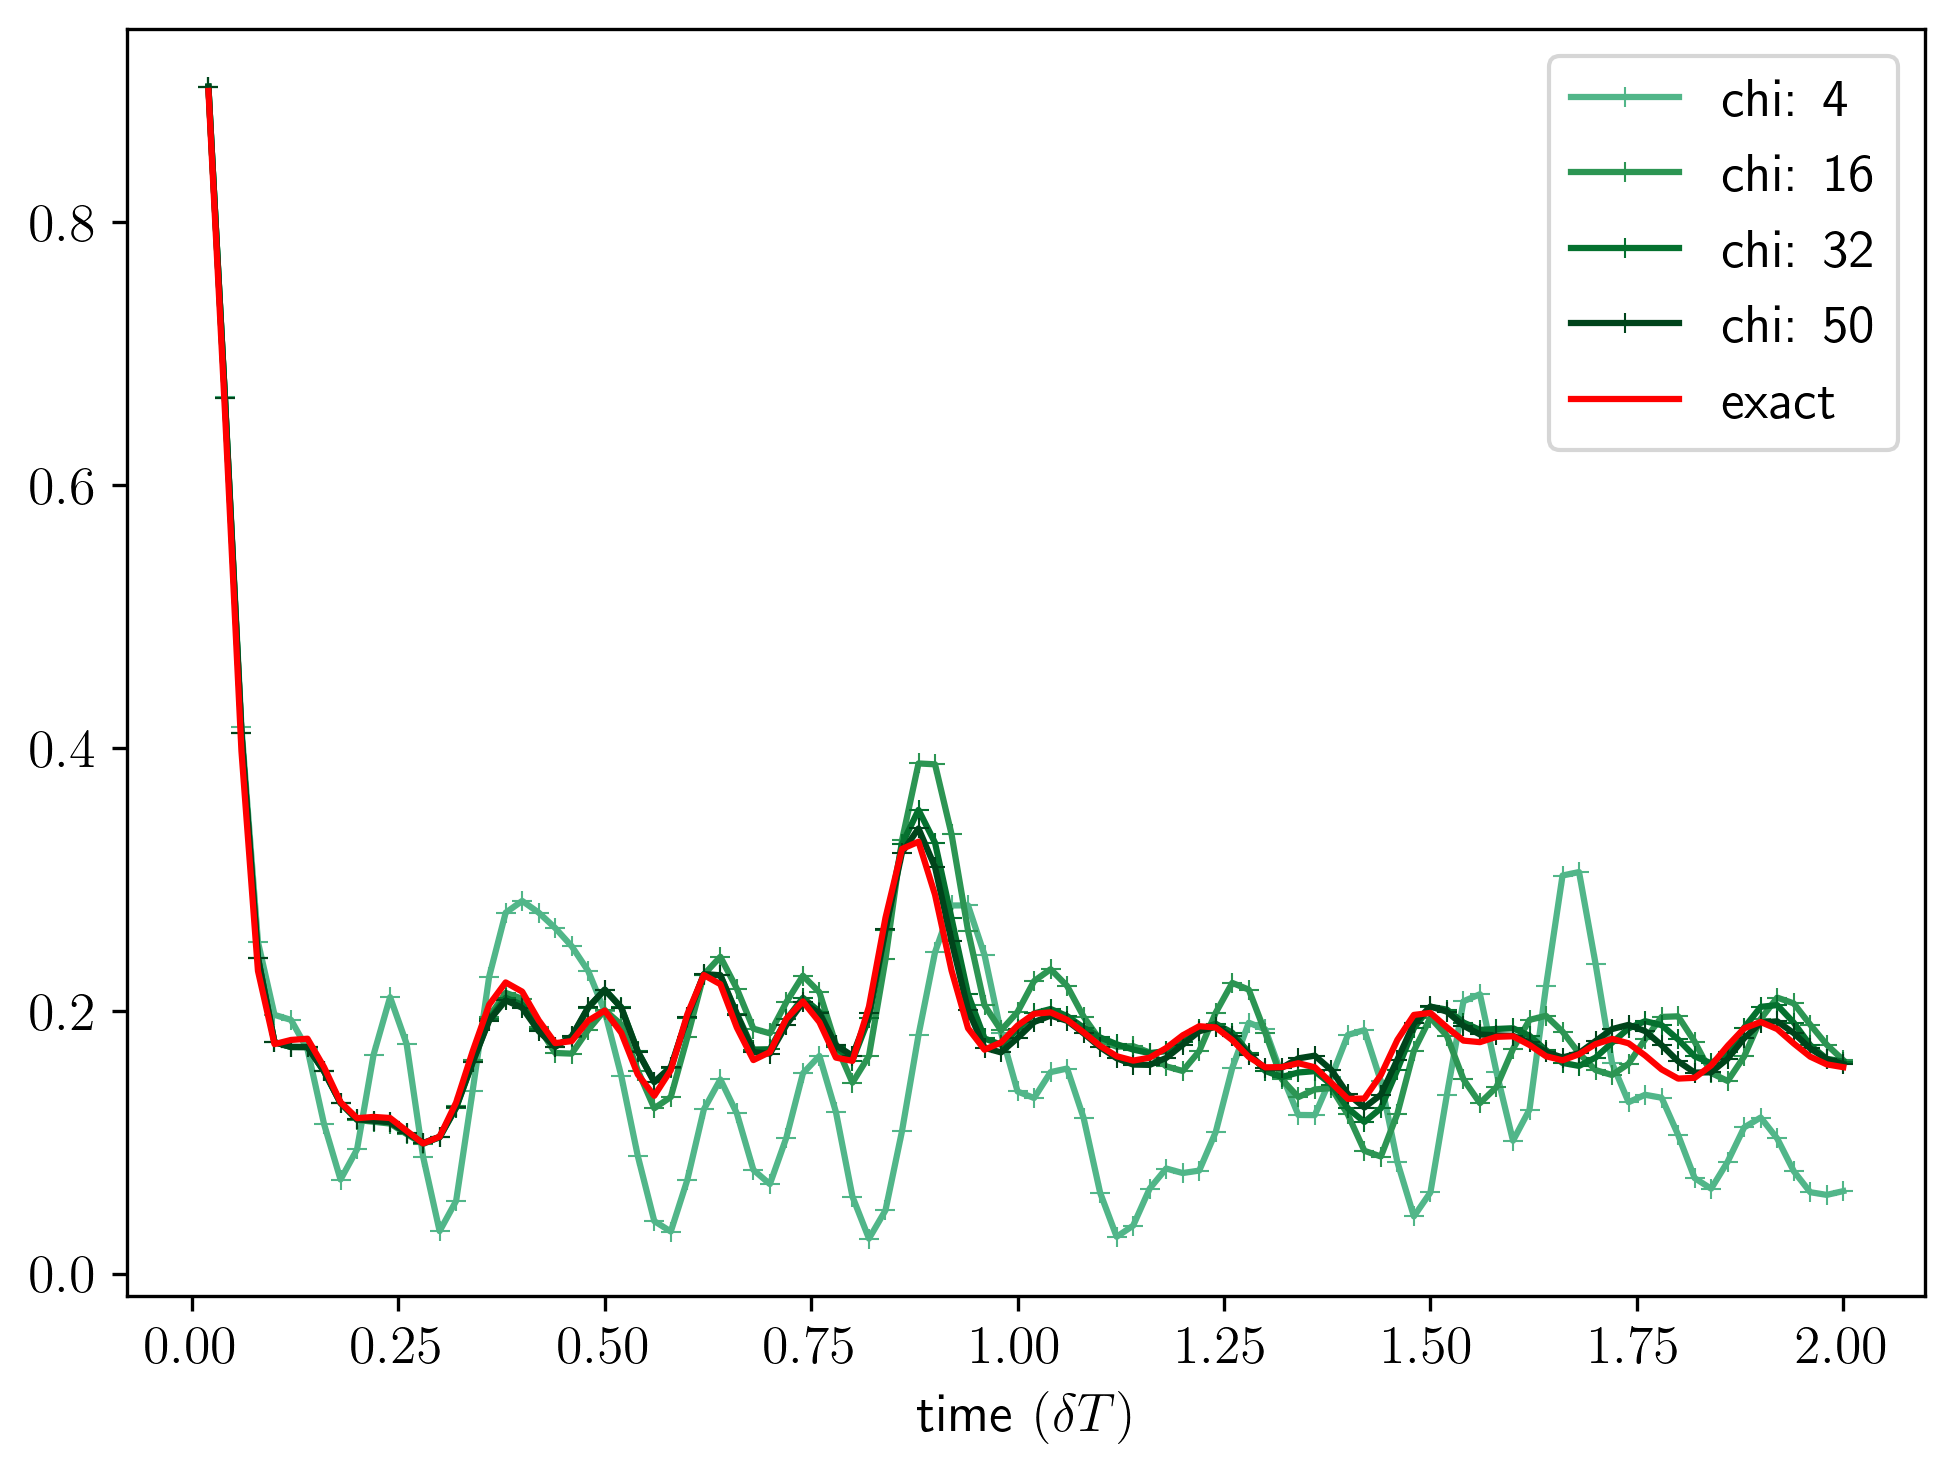

In [ ]:
for i, local_magnetization in enumerate(loc):
    # plt.plot(np.linspace(0,trotter_steps-1, int(trotter_steps*0.3)), np.asarray(local_magnetization)[1:,L//2], '+', markersize=5, mew=0.5, color=colors[len(chis)+i], label=f"chi: {chis[i]}")
    plt.plot(np.linspace(delta,final_time,int(trotter_steps)), np.asarray(local_magnetization)[1:,L//2], '+-', markersize=5, mew=0.5, color=colors[len(chis)+i], label=f"chi: {chis[i]}")

plt.plot(np.linspace(delta,final_time,trotter_steps), np.asarray(exp_vals[0])[:,L//2], 'r', linewidth=1.5, label='exact')
plt.legend()
plt.xlabel("time $(\\delta T)$")

In [ ]:
np.asarray(exp_vals[0]).shape, L//2

((100, 12), 6)

## Big test

### Exact

In [27]:
half_chain_length = 5
L = 2*half_chain_length + 2
t_up = 1
t_down = 1
tp_up = 16
tp_down = 16
Jz = 10
J_perp = 1
eps = 0
V = 0
trotter_steps = 100
final_time = 2
delta = final_time / trotter_steps

In [28]:
spin_up = np.array([1,0,0])
hole = np.array([0,1,0])
spin_down = np.array([0,0,1])

H_ev, psi_init = half_hole_quench_init(half_chain_length, t_up, t_down, Jz, J_perp, eps, V, tp_up=tp_up, tp_down=tp_down, n_holes=2)

# psi_init = kron(spin_up, kron(spin_down, kron(spin_up, kron(hole, kron(hole, kron(spin_up, kron(spin_down, spin_up))))))).T.toarray()
# psi_init = kron(spin_down, kron(spin_up, kron(spin_down, kron(hole, kron(hole, kron(spin_down, kron(spin_up, spin_down))))))).T.toarray()
# psi_init = kron(spin_up, kron(spin_down, kron(spin_up, kron(hole, kron(hole, kron(spin_down, kron(spin_up, spin_down))))))).T.toarray()
# psi_init = kron(spin_down, kron(spin_up, kron(spin_down, kron(hole, kron(hole, kron(spin_up, kron(spin_down, spin_up))))))).T.toarray()
# psi_init = kron(hole, kron(hole, kron(spin_up, kron(hole, hole)))).T.toarray()
# psi_init = kron(hole, kron(hole, kron(spin_up, kron(spin_up, kron(hole, hole))))).T.toarray()

psi_init = kron(hole, kron(hole, kron(hole, kron(hole, kron(hole, kron(spin_up, kron(spin_up, kron(hole, kron(hole, kron(hole, kron(hole, hole))))))))))).T.toarray()
psi_init = kron(spin_up, kron(spin_down, kron(spin_up, kron(spin_down, kron(spin_up, kron(hole, kron(hole, kron(spin_up, kron(spin_down, kron(spin_up, kron(spin_down, spin_up))))))))))).T.toarray()
# psi_init = psi_init.reshape((3**6))
psi_init = psi_init.reshape((3**(2*half_chain_length+2)))

# H_ev = tJV_ham(n=2*half_chain_length+2, t_up=t_up, t_down=t_down, Jz=Jz, J_perp=J_perp, eps=eps, V=V)
exp_vals, psi_save = half_hole_quench_evolution(half_chain_length, H_ev, psi_init, trotter_steps, final_time, obs=['h_loc'], n_holes=2, save=False)

Trotter step: 0
Trotter step: 1
Trotter step: 2
Trotter step: 3
Trotter step: 4
Trotter step: 5
Trotter step: 6
Trotter step: 7
Trotter step: 8
Trotter step: 9
Trotter step: 10
Trotter step: 11
Trotter step: 12
Trotter step: 13
Trotter step: 14
Trotter step: 15
Trotter step: 16
Trotter step: 17
Trotter step: 18
Trotter step: 19
Trotter step: 20
Trotter step: 21
Trotter step: 22
Trotter step: 23
Trotter step: 24
Trotter step: 25
Trotter step: 26
Trotter step: 27
Trotter step: 28
Trotter step: 29
Trotter step: 30
Trotter step: 31
Trotter step: 32
Trotter step: 33
Trotter step: 34
Trotter step: 35
Trotter step: 36
Trotter step: 37
Trotter step: 38
Trotter step: 39
Trotter step: 40
Trotter step: 41
Trotter step: 42
Trotter step: 43
Trotter step: 44
Trotter step: 45
Trotter step: 46
Trotter step: 47
Trotter step: 48
Trotter step: 49
Trotter step: 50
Trotter step: 51
Trotter step: 52
Trotter step: 53
Trotter step: 54
Trotter step: 55
Trotter step: 56
Trotter step: 57
Trotter step: 58
Trotter

### TEBD

In [18]:
path = "D:/code/projects/6_TJ/results"

chis = [50,100,150,200,250,300,350]

def load_obs_chi(obs: str="svs", chi: int=50):
    if obs == "svs":
        return np.load(f"{path}/svs_data/time_ev_svs_L_{L}_tj_model_delta_{delta}_chi_{chi}.npy")
    if obs == "err":
        return np.load(f"{path}/error_data/time_ev_errors_L_{L}_tj_model_delta_{delta}_chi_{chi}.npy")
    if obs == "entr":
        return np.load(f"{path}/entropy_data/time_ev_entropy_L_{L}_tj_model_delta_{delta}_chi_{chi}.npy")
    if obs == "mag":
        return np.load(f"{path}/mag_data/time_ev_hole_occup_L_{L}_tj_model_delta_{delta}_chi_{chi}.npy")

<>:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_39116\24213115.py:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.plot(sv_chi[:,-1], color=colors[i], label=f"$\chi = {chi}$")


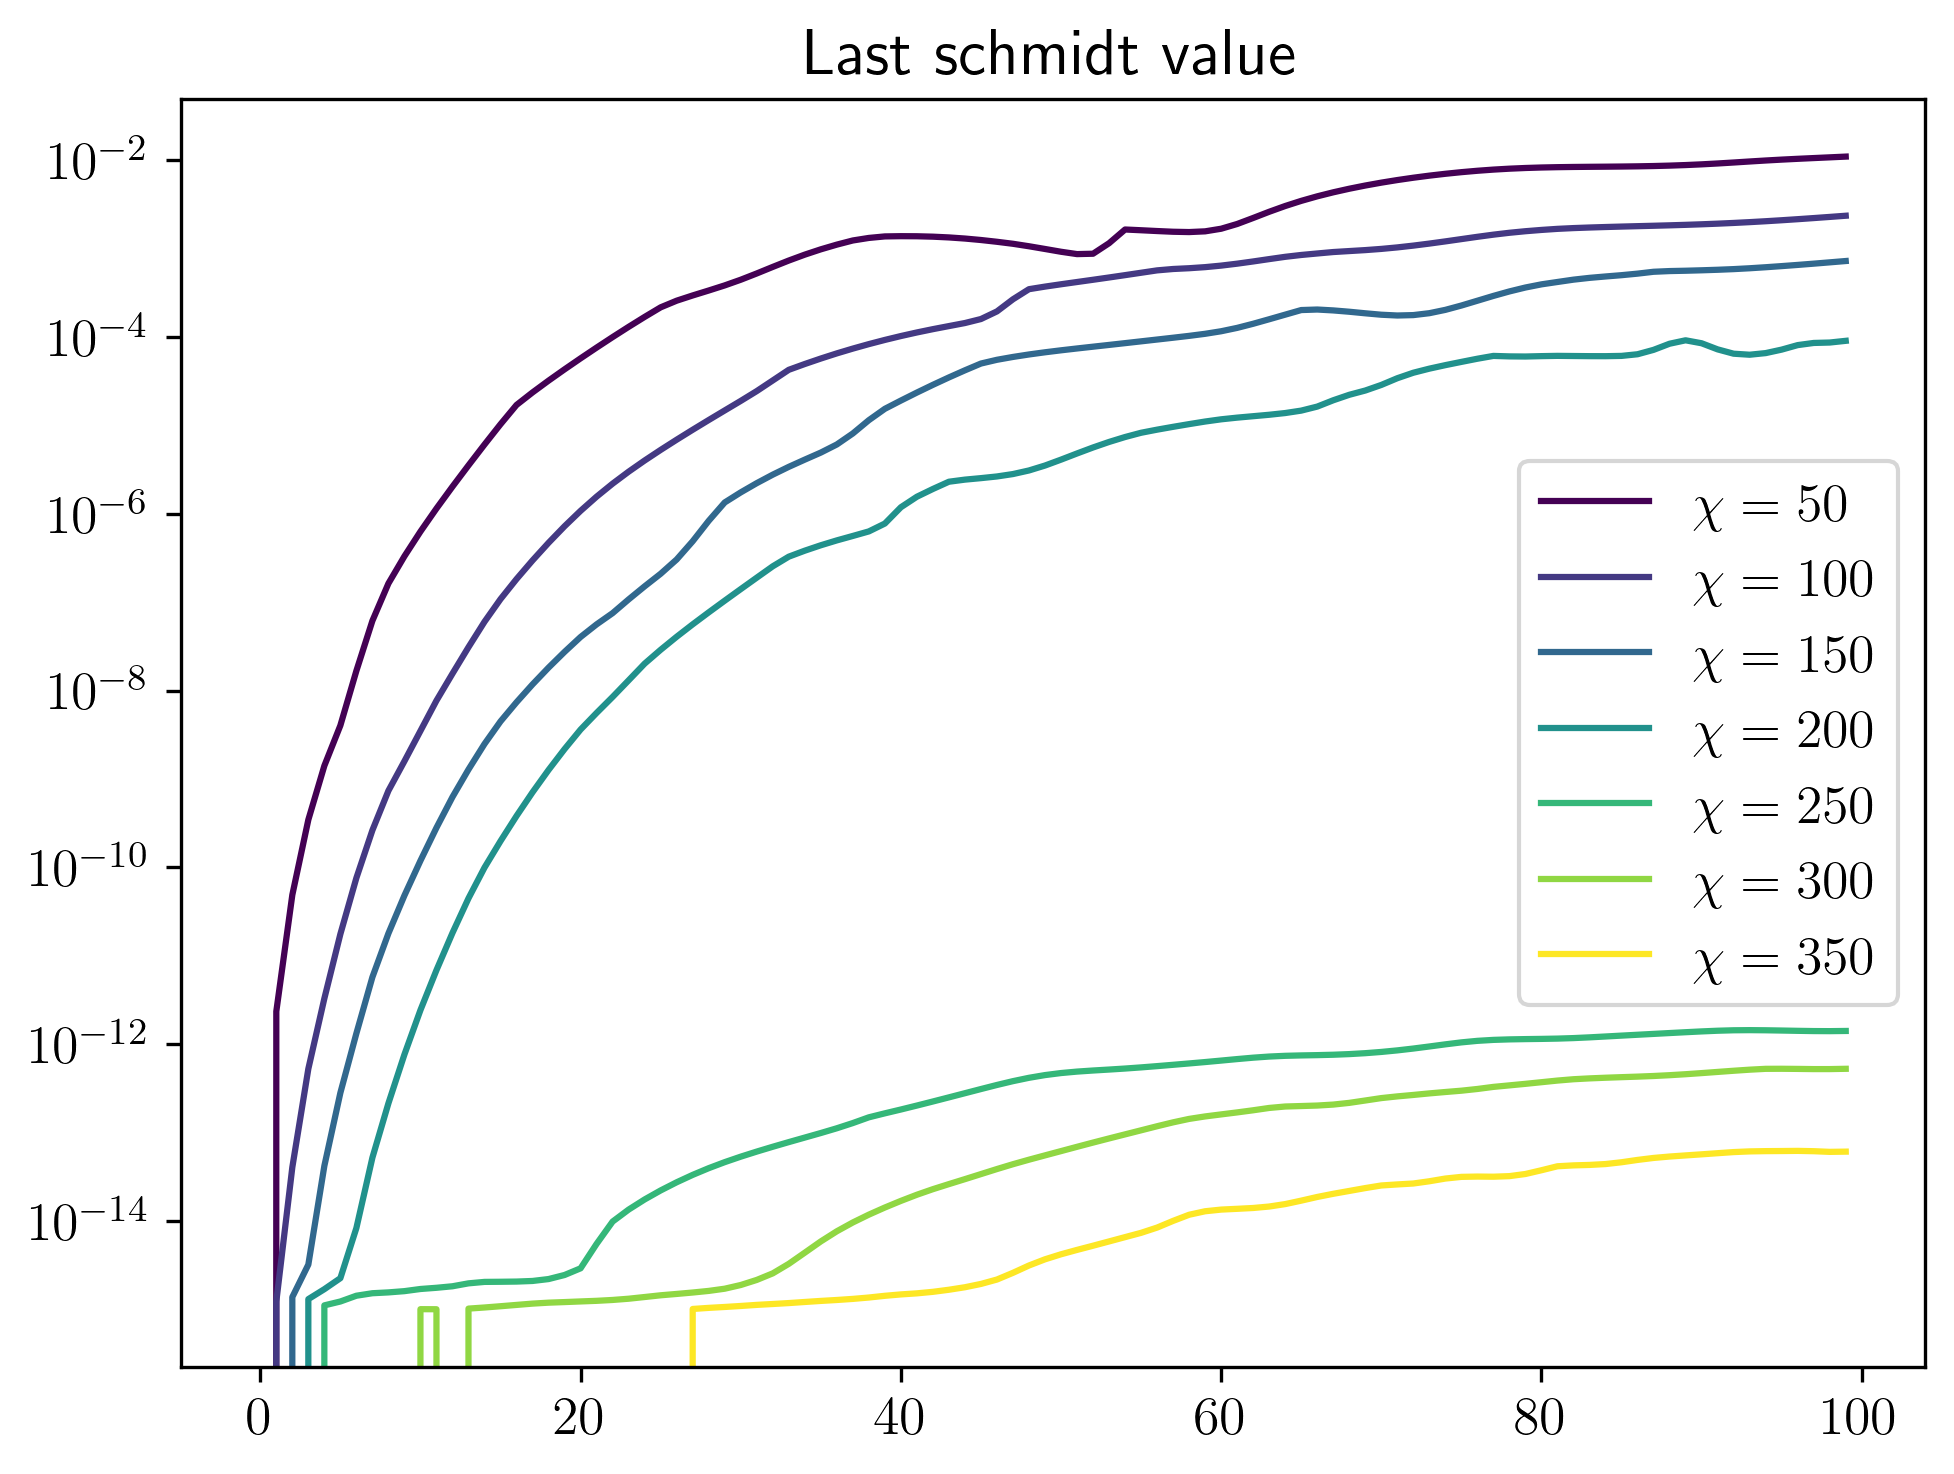

In [19]:
obs = "svs"
colors = create_sequential_colors(len(chis))

i = 0
for chi in chis:
    sv_chi = load_obs_chi(obs, chi)
    plt.plot(sv_chi[:,-1], color=colors[i], label=f"$\chi = {chi}$")
    i += 1
plt.yscale('log')
plt.title("Last schmidt value")
plt.legend()

<>:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_39116\2165157860.py:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.plot(err_chi, color=colors[i], label=f"$\chi = {chi}$")


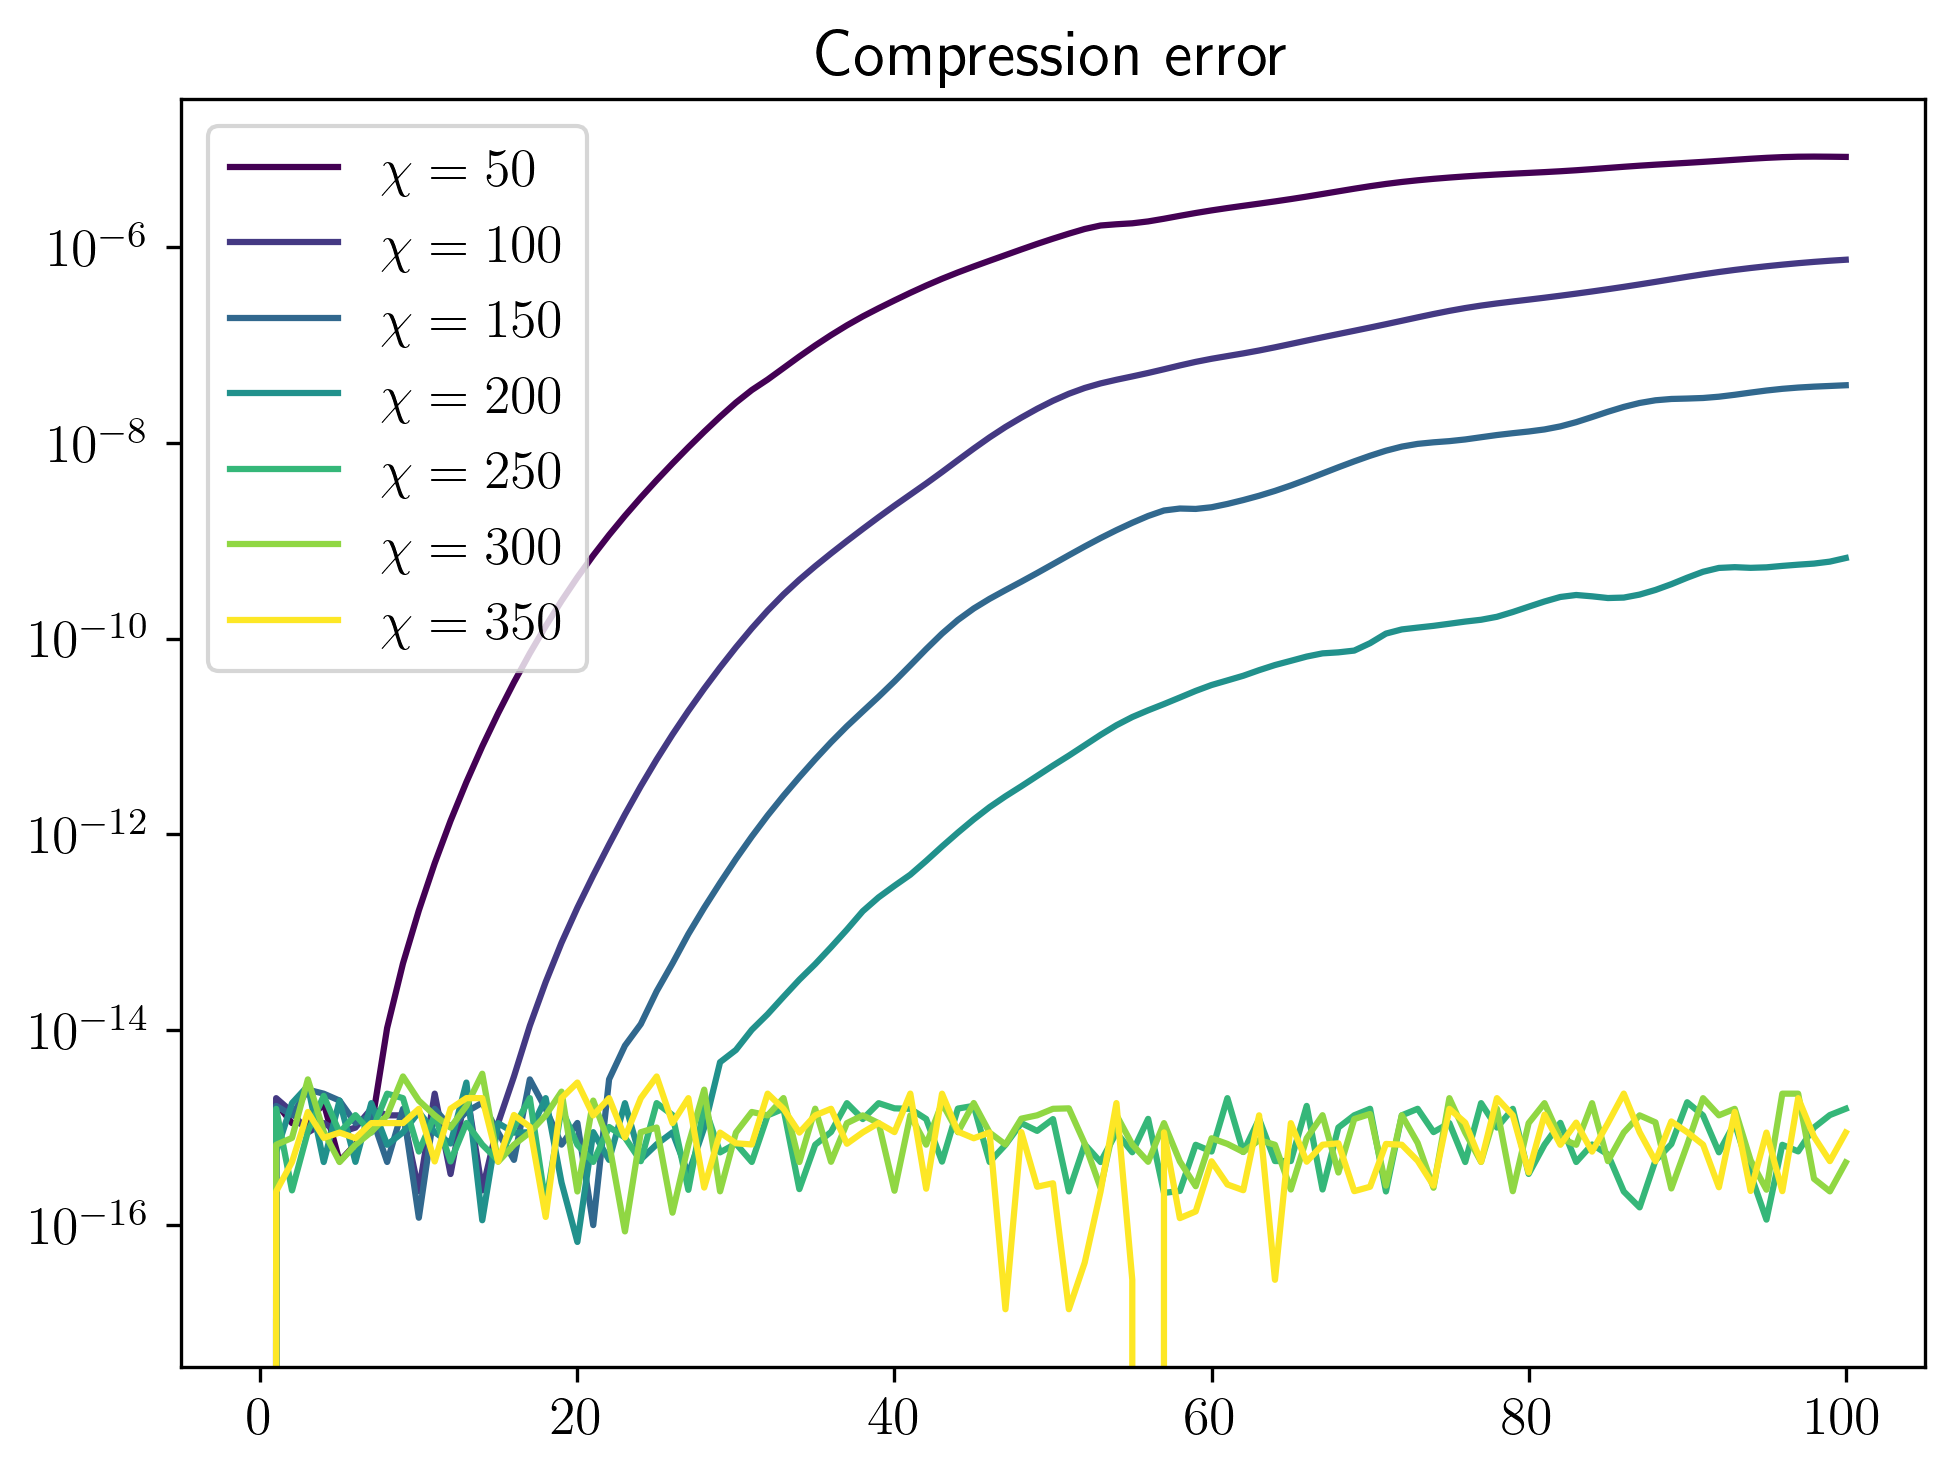

In [20]:
obs = "err"
colors = create_sequential_colors(len(chis))

i = 0
for chi in chis:
    err_chi = load_obs_chi(obs, chi)
    plt.plot(err_chi, color=colors[i], label=f"$\chi = {chi}$")
    i += 1
plt.yscale('log')
plt.title("Compression error")
plt.legend()

<>:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_39116\733250452.py:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.plot(hole_chi[:,L//2], color=colors[i], label=f"$\chi = {chi}$")


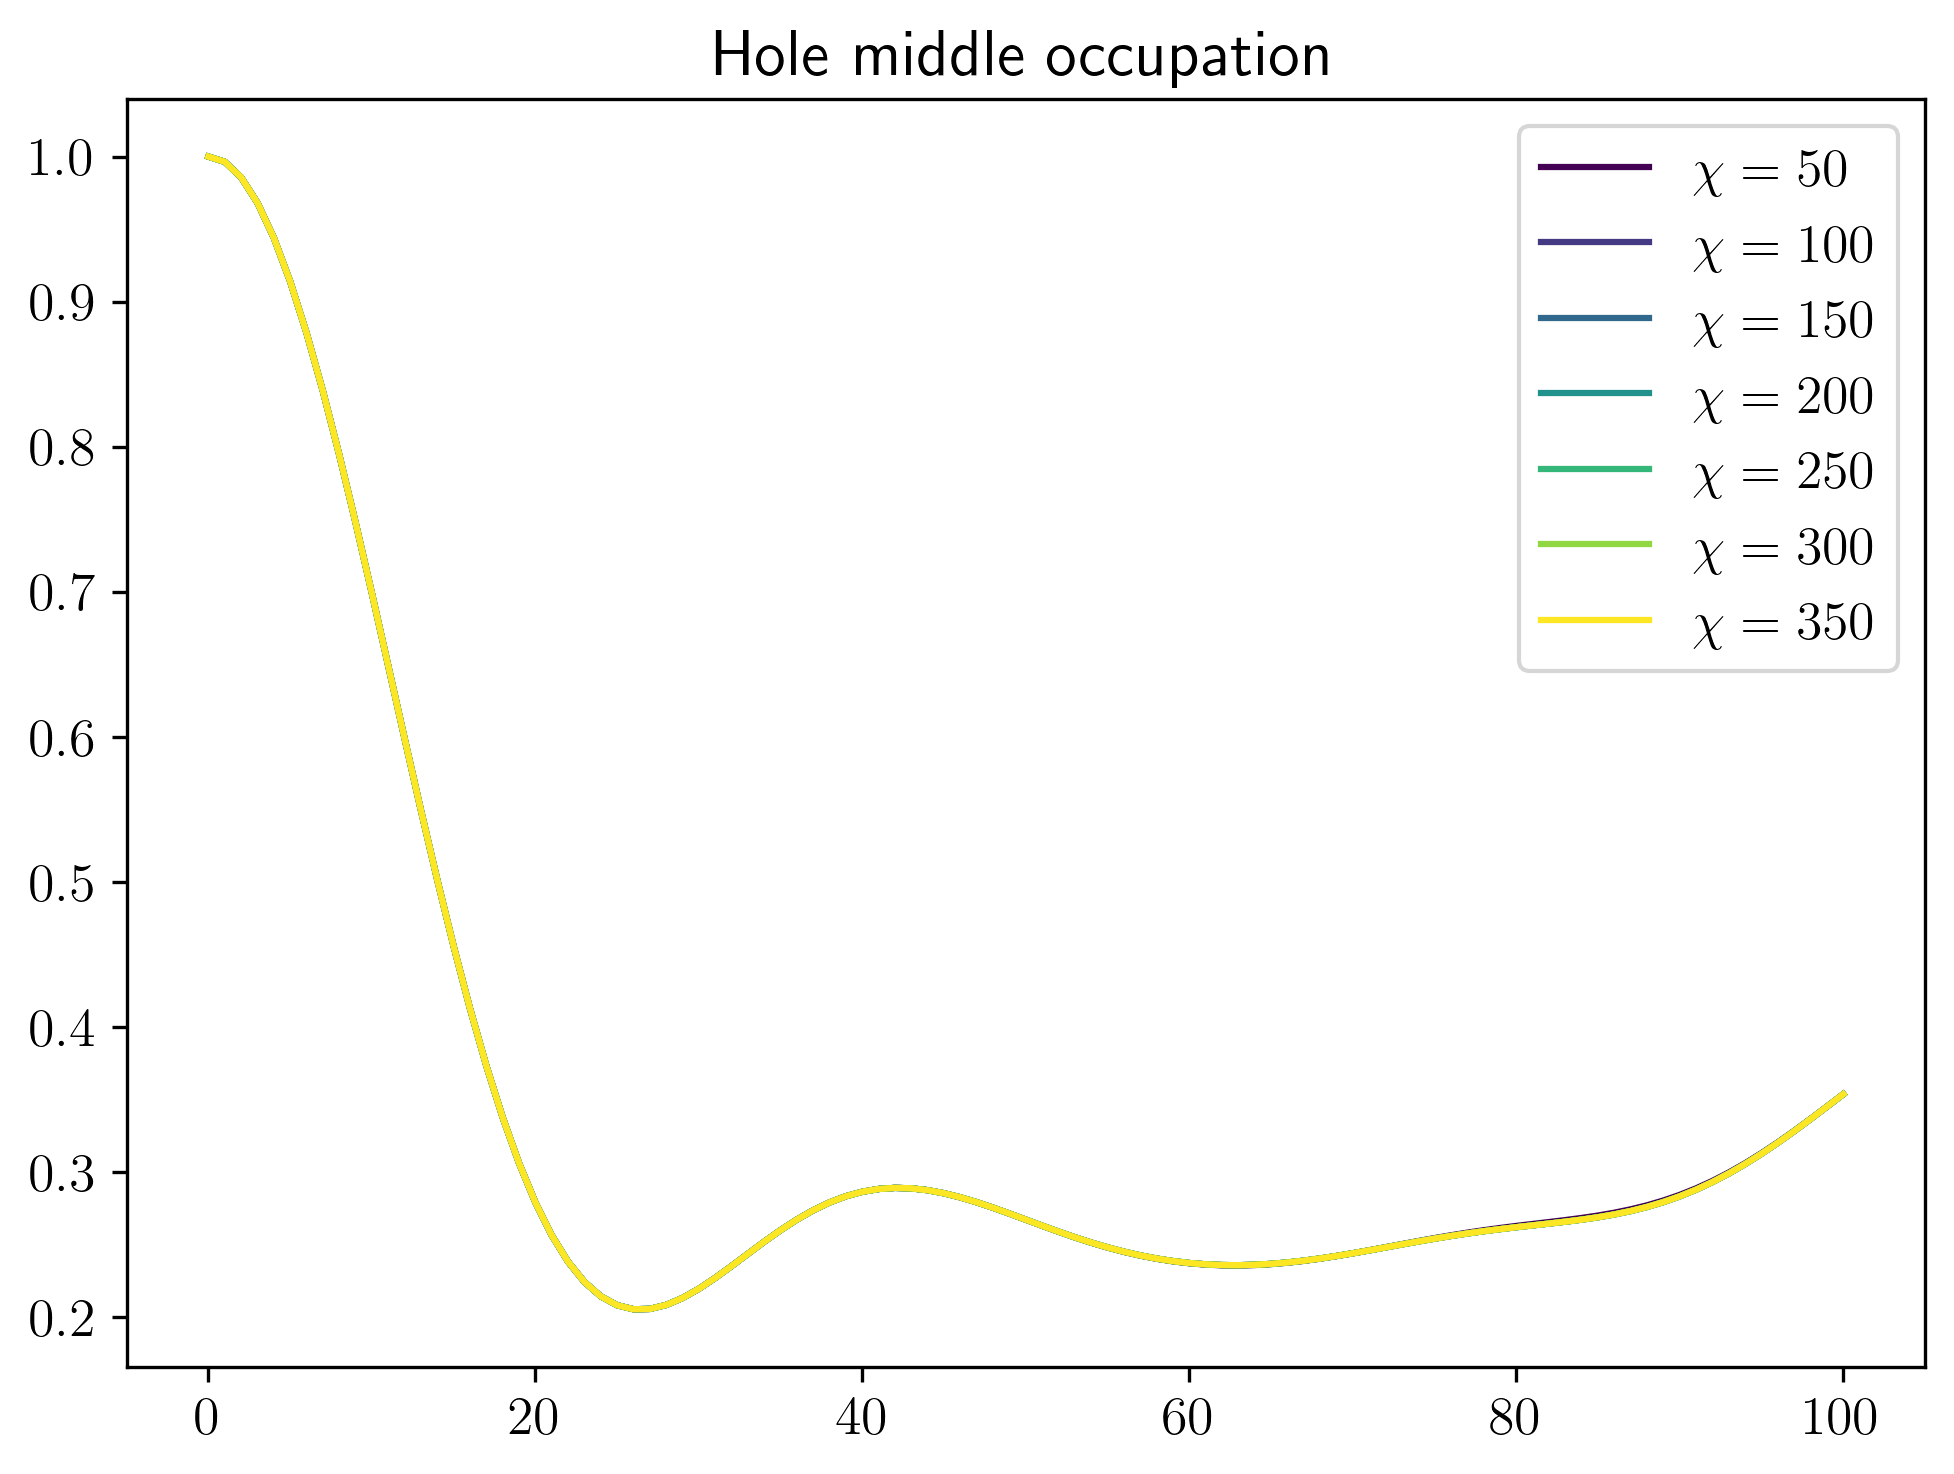

In [22]:
obs = "mag"
colors = create_sequential_colors(len(chis))

i = 0
for chi in chis:
    hole_chi = load_obs_chi(obs, chi)
    plt.plot(hole_chi[:,L//2], color=colors[i], label=f"$\chi = {chi}$")
    i += 1
plt.title("Hole middle occupation")
plt.legend()

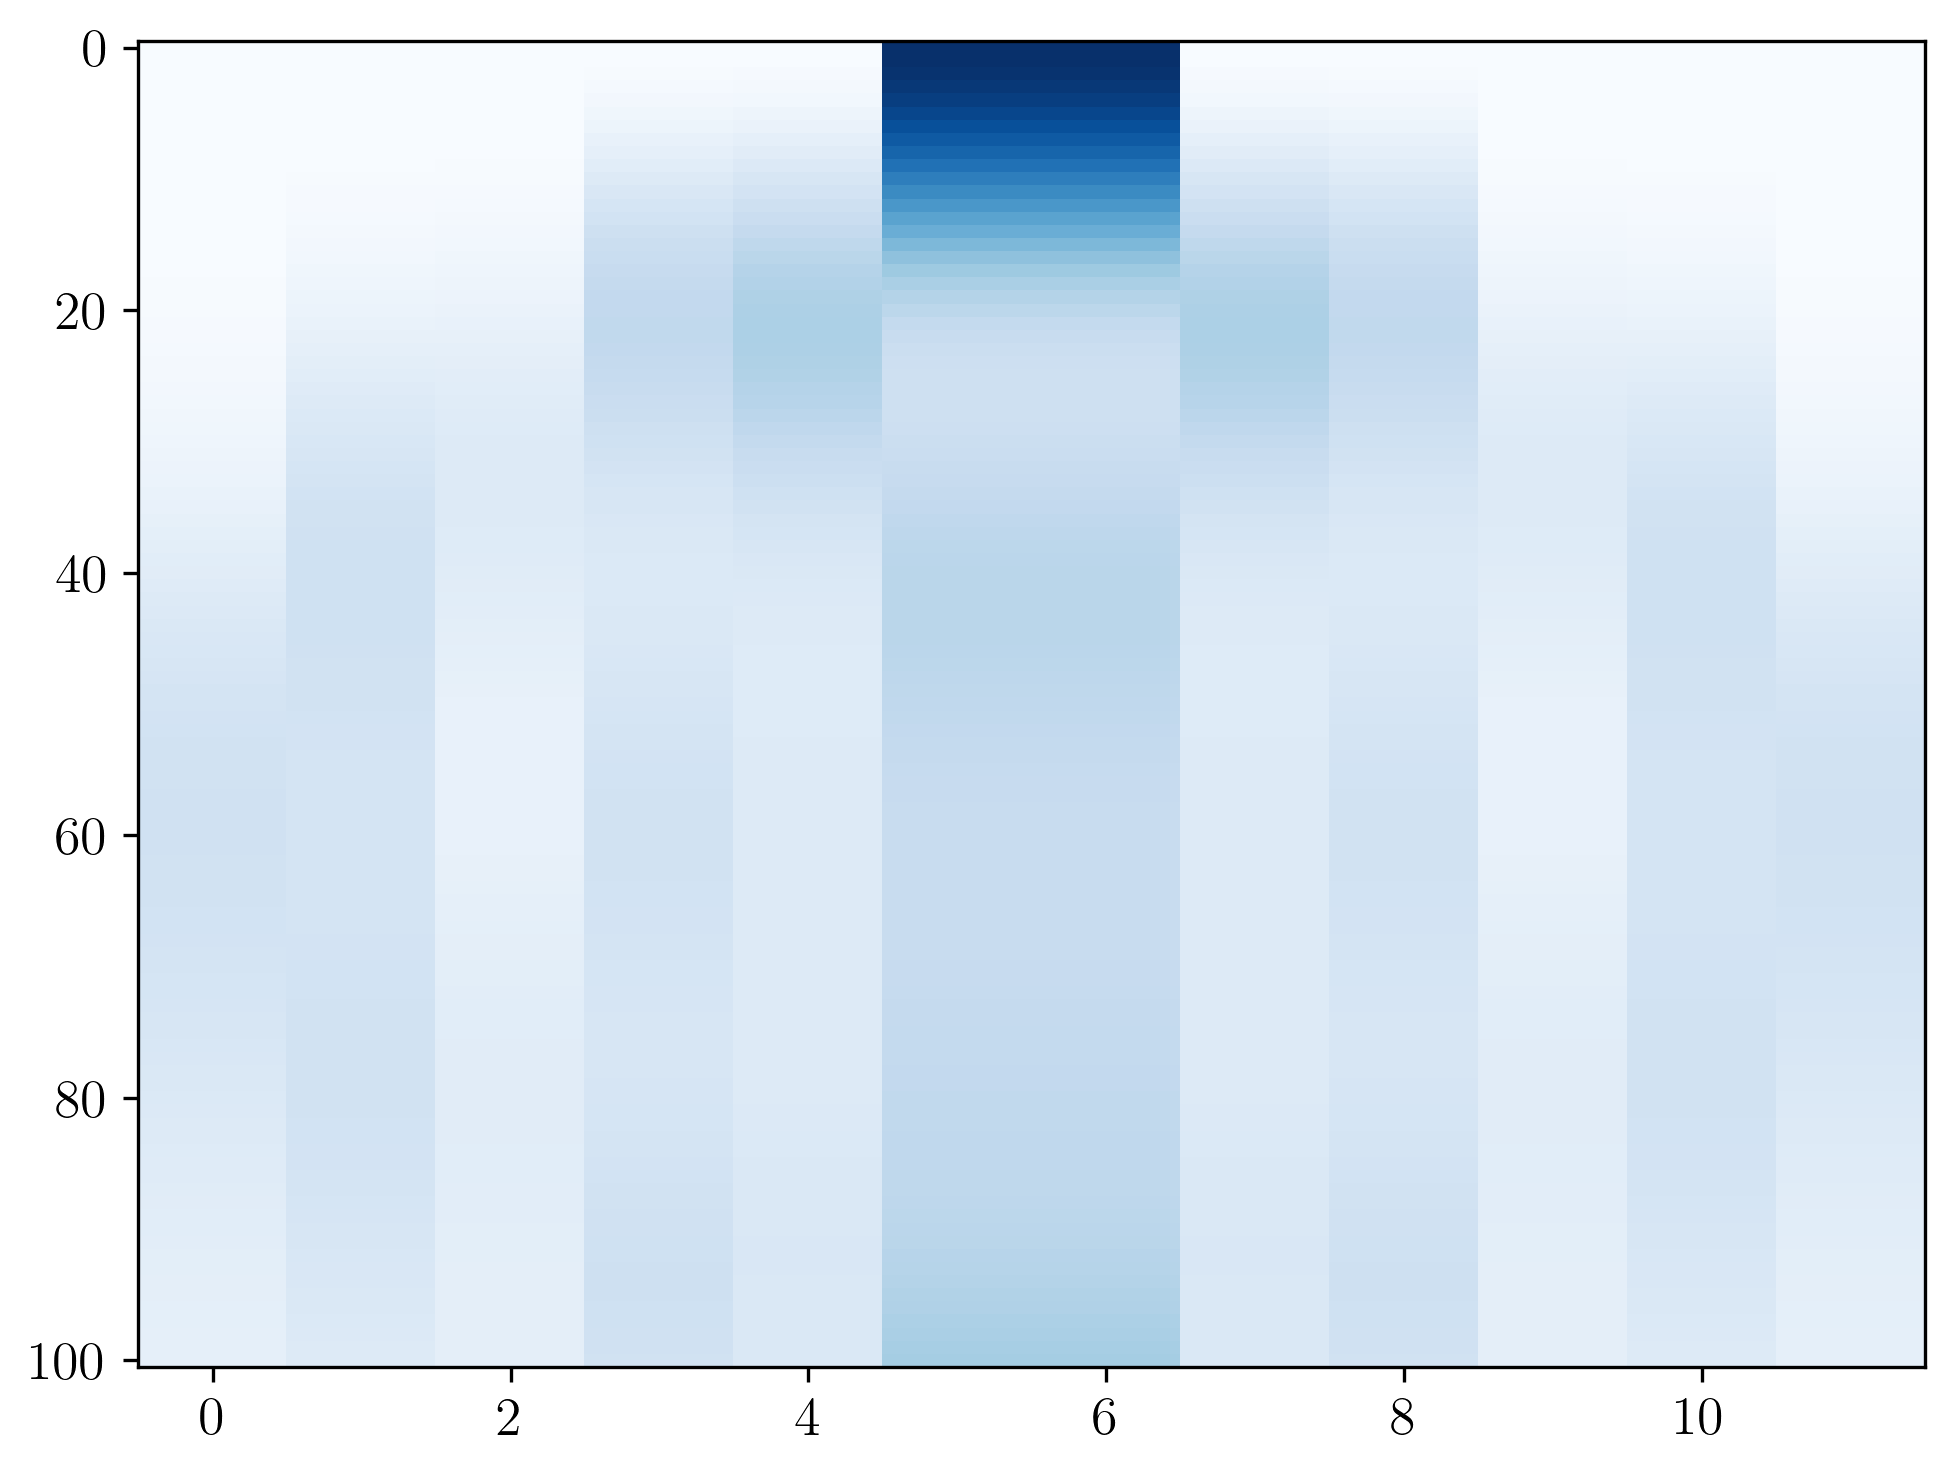

In [24]:
local_hole_occup = load_obs_chi("mag", chis[-1])
plt.imshow(local_hole_occup, cmap="Blues", aspect='auto')

<>:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_39116\2461074368.py:7: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.plot(hole_chi[:,L//2], '+', color=colors[i], label=f"$\chi = {chi}$")


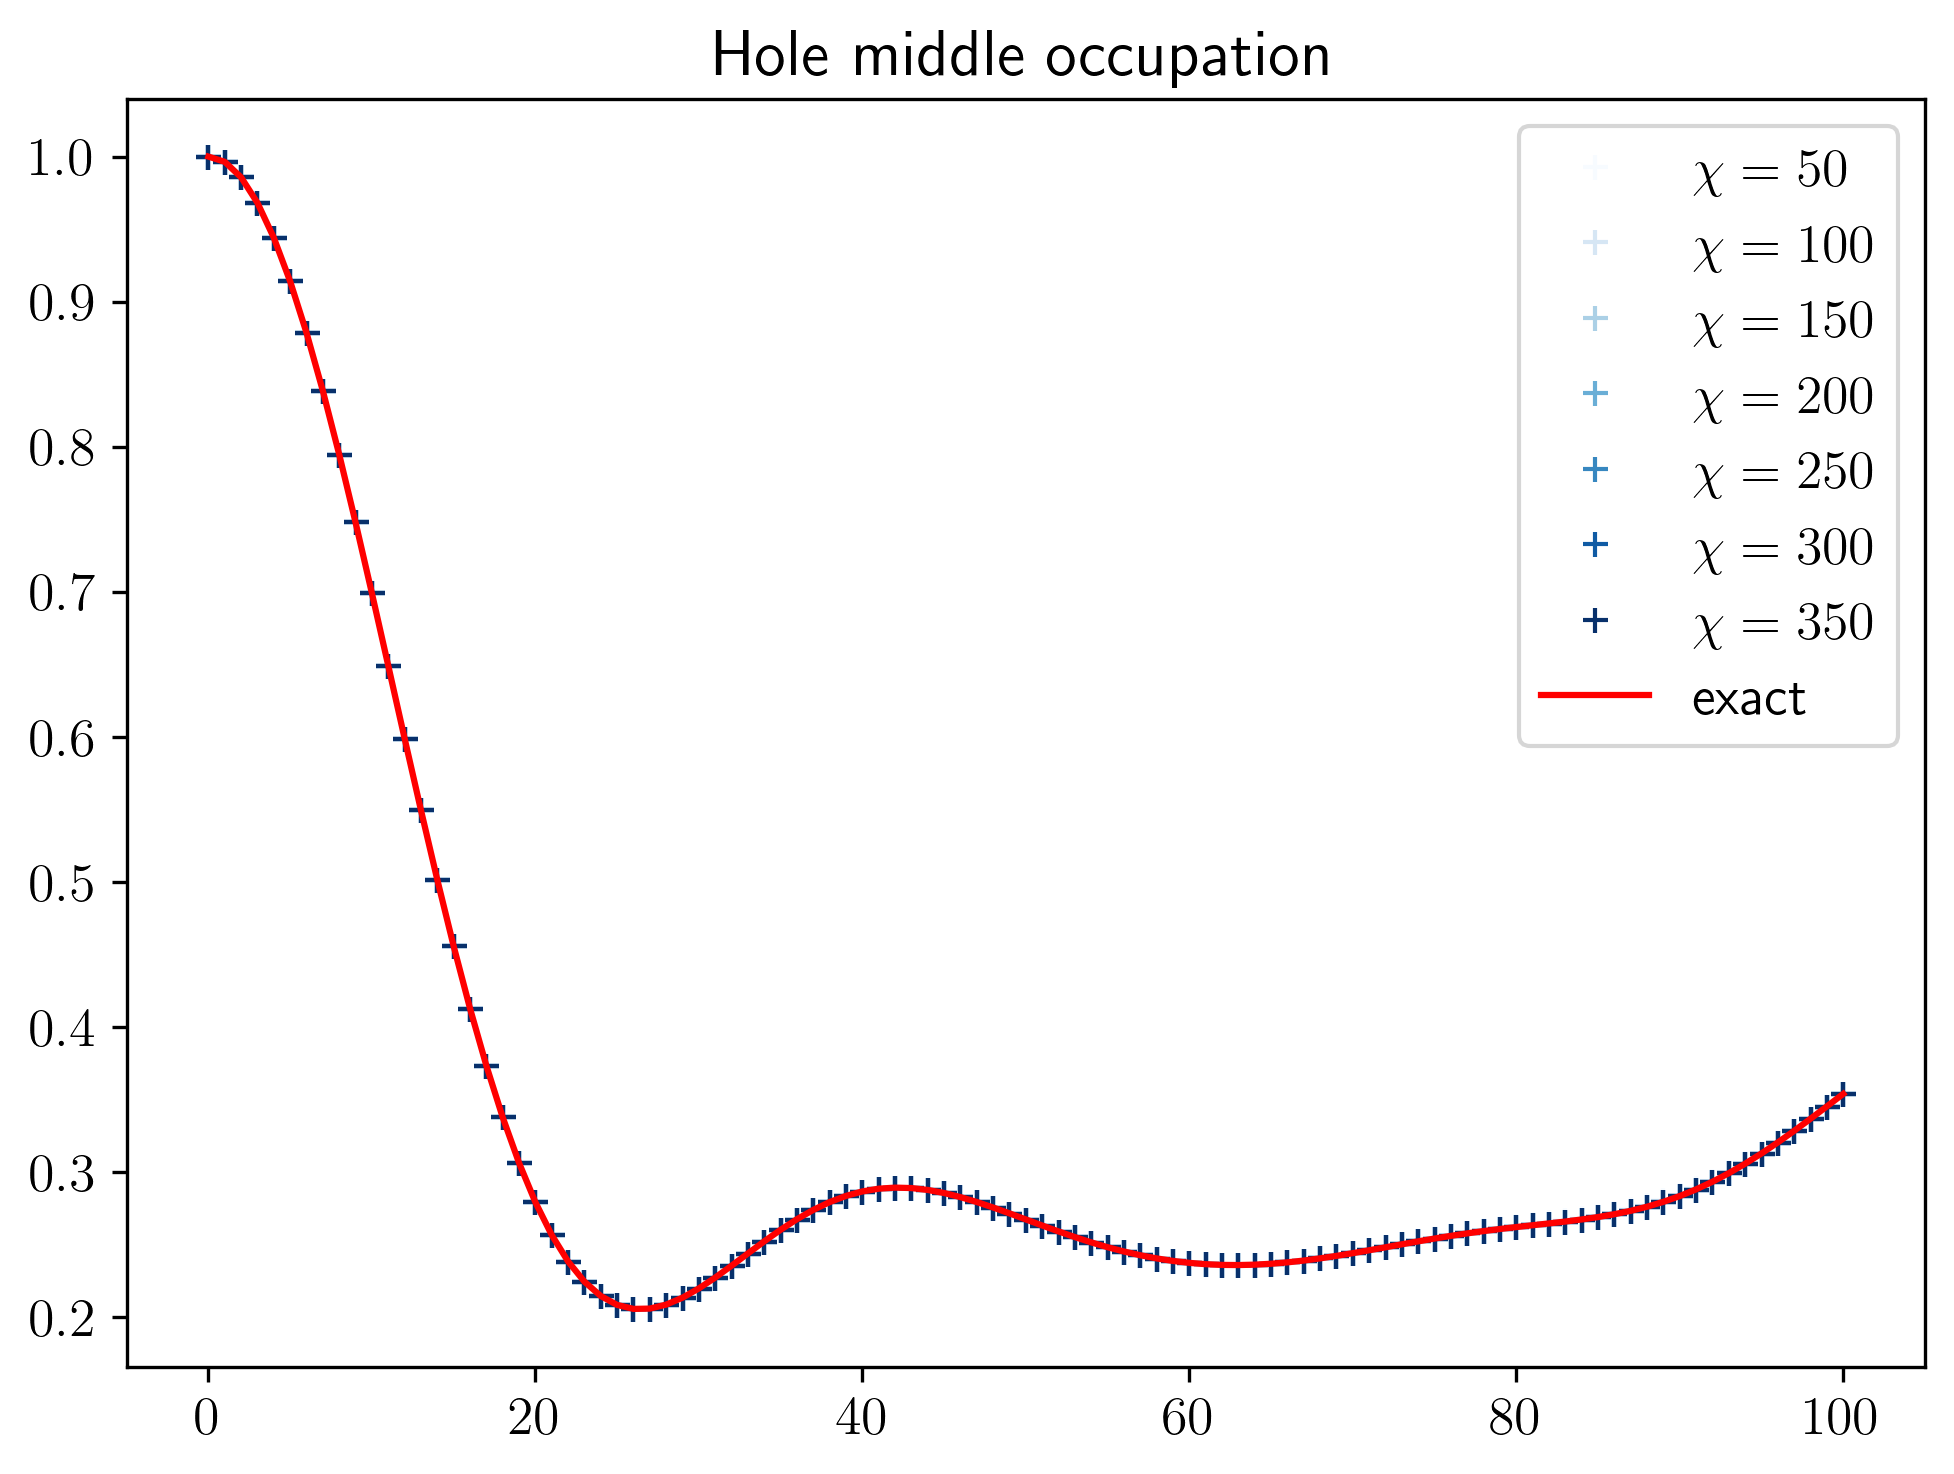

In [39]:
obs = "mag"
colors = create_sequential_colors(len(chis), colormap_name="Blues")

i = 0
for chi in chis:
    hole_chi = load_obs_chi(obs, chi)
    plt.plot(hole_chi[:,L//2], '+', color=colors[i], label=f"$\chi = {chi}$")
    i += 1

new_list = [[0,0,0,0,0,1,1,0,0,0,0,0]] + exp_vals[0]
plt.plot(np.asarray(new_list)[:,L//2], 'r', linewidth=1.5, label='exact')
plt.title("Hole middle occupation")
plt.legend()

<>:8: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:11: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:8: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:11: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_39116\3978831380.py:8: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.plot(abs(np.asarray(new_list)[:,L//2] - hole_chi[:,L//2]), color=colors[i+5+2*i], label=f"$\chi = {chi}$")
C:\Users\HP\AppData\Local\Temp\ipykernel_39116\3978831380.py:1

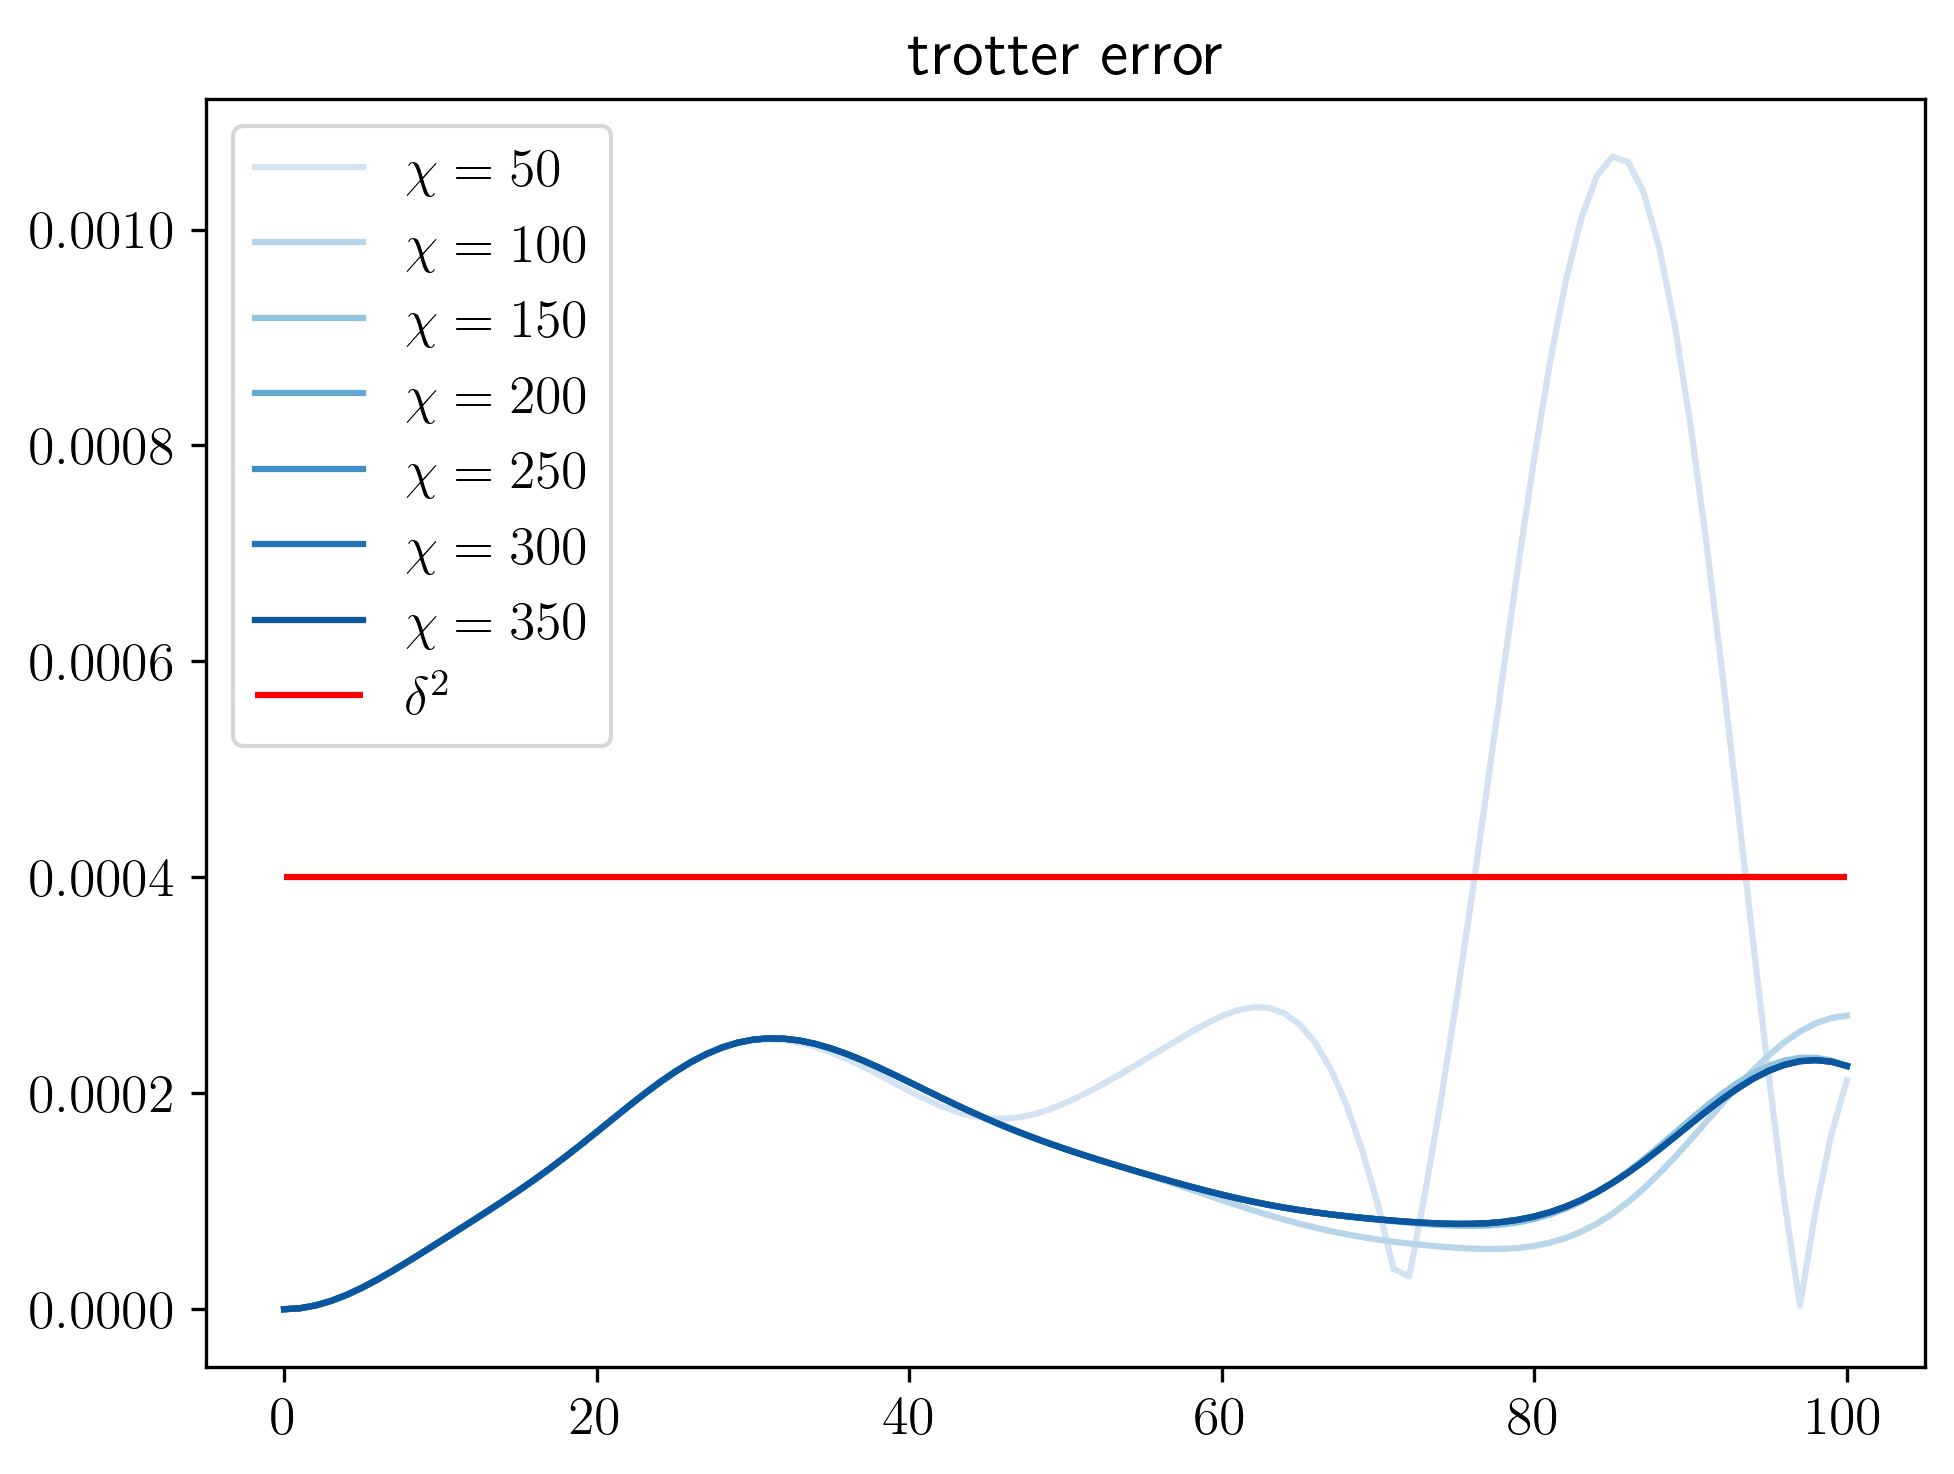

In [42]:
obs = "mag"
colors = create_sequential_colors(len(chis)*4, colormap_name="Blues")

new_list = [[0,0,0,0,0,1,1,0,0,0,0,0]] + exp_vals[0]
i = 0
for chi in chis:
    hole_chi = load_obs_chi(obs, chi)
    plt.plot(abs(np.asarray(new_list)[:,L//2] - hole_chi[:,L//2]), color=colors[i+5+2*i], label=f"$\chi = {chi}$")
    i += 1

plt.hlines(delta**2, xmin=0, xmax=trotter_steps, color='r', linewidth=1.5, label='$\delta^2$')
plt.title("trotter error")
plt.legend()